In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import (roc_auc_score,roc_curve)
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score


In [2]:
from sklearn.linear_model import LogisticRegression

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score,confusion_matrix, classification_report,roc_auc_score, roc_curve)

In [4]:
print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
hotel_df = pd.read_csv('hotel_bookings.csv')

In [6]:
print(f"Total Records : {hotel_df.shape[0]:,}")

Total Records : 119,390


In [7]:
print(f"Total Features: {hotel_df.shape[1]}")

Total Features: 32


In [8]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [9]:
hotel_df.shape

(119390, 32)

# Data Preprocessing

In [10]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [11]:
hotel_df.shape

(119390, 32)

### Duplicate Rows Check

In [12]:
print("=" * 45)
print("DUPLICATE ROWS CHECK")
print("=" * 45)

# Total duplicates count
duplicates = hotel_df.duplicated().sum()
total      = len(hotel_df)

print(f"Total Rows        : {total:,}")
print(f"Duplicate Rows    : {duplicates:,}")
print(f"Duplicate %       : {duplicates/total*100:.2f}%")
print(f"Unique Rows       : {total - duplicates:,}")

if duplicates > 0:
    print(f"\n {duplicates:,} duplicate rows found — need to remove!")
else:
    print("\n No duplicates found!")

DUPLICATE ROWS CHECK
Total Rows        : 119,390
Duplicate Rows    : 31,994
Duplicate %       : 26.80%
Unique Rows       : 87,396

 31,994 duplicate rows found — need to remove!


## Duplicate Row Remove 

In [13]:
before = len(hotel_df)
hotel_df = hotel_df.drop_duplicates()
after  = len(hotel_df)

print(f"Before : {before:,} rows")
print(f"After  : {after:,} rows")
print(f"Removed: {before - after:,} duplicate rows")

Before : 119,390 rows
After  : 87,396 rows
Removed: 31,994 duplicate rows


In [14]:
hotel_df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 87396, dtype: bool

In [15]:
hotel_df.duplicated().sum()

np.int64(0)

### Null Values check

In [16]:
hotel_df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [17]:
print("=" * 45)
print("HANDLING MISSING VALUES")
print("=" * 45)

# 1. Drop agent and company — too many nulls
hotel_df = hotel_df.drop(columns=['agent', 'company'])
print(" Dropped  : agent (12,193 nulls)")
print(" Dropped  : company (82,137 nulls)")

# 2. Fill children nulls with 0
hotel_df['children'] = hotel_df['children'].fillna(0)
print(" Filled   : children → 0")

# 3. Fill country nulls with mode
hotel_df['country'] = hotel_df['country'].fillna(
                      hotel_df['country'].mode()[0])
print(" Filled   : country → mode value")

# Verify — no nulls remaining
print()
print("=" * 45)
print("VERIFY — NULL VALUES AFTER FIX")
print("=" * 45)
remaining = hotel_df.isnull().sum().sum()
print(f"Remaining null values : {remaining}")

if remaining == 0:
    print(" All missing values handled!")
else:
    print(f" {remaining} nulls still remaining!")

HANDLING MISSING VALUES
 Dropped  : agent (12,193 nulls)
 Dropped  : company (82,137 nulls)
 Filled   : children → 0
 Filled   : country → mode value

VERIFY — NULL VALUES AFTER FIX
Remaining null values : 0
 All missing values handled!


In [18]:
hotel_df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

### Data Leakage Columns Drop

In [19]:
print("=" * 45)
print("CORRELATION WITH TARGET (is_canceled)")
print("=" * 45)


numeric_df = hotel_df.select_dtypes(include='number')
correlation = numeric_df.corr()['is_canceled'].abs().sort_values(ascending=False)

print(correlation)

CORRELATION WITH TARGET (is_canceled)
is_canceled                       1.000000
lead_time                         0.184806
required_car_parking_spaces       0.184206
adr                               0.127986
total_of_special_requests         0.120545
booking_changes                   0.093644
is_repeated_guest                 0.089643
arrival_date_year                 0.088030
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_bookings_not_canceled    0.052154
previous_cancellations            0.051468
babies                            0.020543
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
Name: is_canceled, dtype: float64


### Outlier Treatment

OUTLIER TREATMENT — adr COLUMN
BEFORE treatment:
  Min adr : -6.38
  Max adr : 5400.00
  Mean adr: 106.34


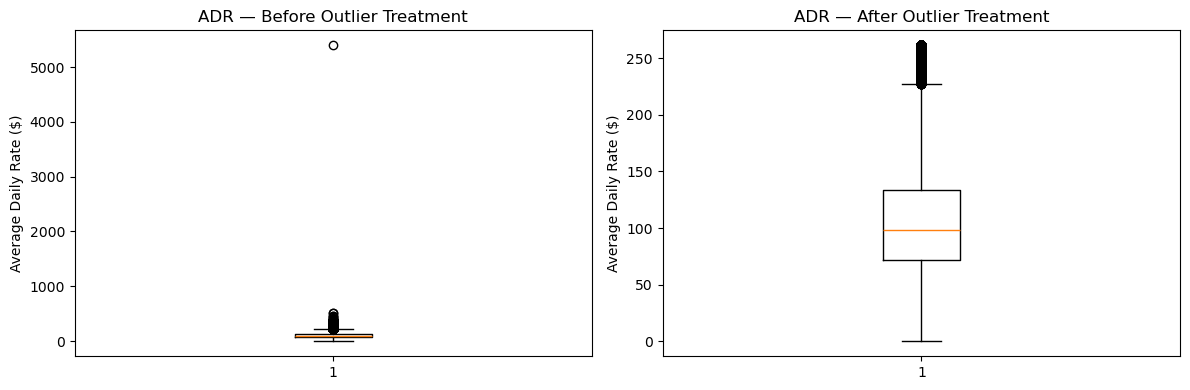


AFTER treatment:
  Min adr : 0.00
  Max adr : 261.41
  Mean adr: 105.95

 Outliers capped at 99th percentile: 261.41


In [20]:
print("=" * 45)
print("OUTLIER TREATMENT — adr COLUMN")
print("=" * 45)

# Before
print("BEFORE treatment:")
print(f"  Min adr : {hotel_df['adr'].min():.2f}")
print(f"  Max adr : {hotel_df['adr'].max():.2f}")
print(f"  Mean adr: {hotel_df['adr'].mean():.2f}")

# Visualise before
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.boxplot(hotel_df['adr'])
plt.title('ADR — Before Outlier Treatment')
plt.ylabel('Average Daily Rate ($)')

# Fix — cap at 99th percentile
adr_cap = hotel_df['adr'].quantile(0.99)
hotel_df['adr'] = hotel_df['adr'].clip(lower=0, upper=adr_cap)

# Visualise after
plt.subplot(1, 2, 2)
plt.boxplot(hotel_df['adr'])
plt.title('ADR — After Outlier Treatment')
plt.ylabel('Average Daily Rate ($)')

plt.tight_layout()
plt.savefig('outlier_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

# After
print("\nAFTER treatment:")
print(f"  Min adr : {hotel_df['adr'].min():.2f}")
print(f"  Max adr : {hotel_df['adr'].max():.2f}")
print(f"  Mean adr: {hotel_df['adr'].mean():.2f}")
print(f"\n Outliers capped at 99th percentile: {adr_cap:.2f}")

### Label Encoding

In [21]:
print("=" * 45)
print("LABEL ENCODING — TEXT TO NUMBERS")
print("=" * 45)

from sklearn.preprocessing import LabelEncoder

# Find all text (object) columns
cat_cols = hotel_df.select_dtypes(include='object').columns.tolist()

print(f"Text columns found : {len(cat_cols)}")
print(f"Columns            : {cat_cols}")
print()

# Encode each column
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    hotel_df[col] = le.fit_transform(hotel_df[col].astype(str))
    le_dict[col]  = le
    print(f" Encoded : {col}")

print()
print("=" * 45)
print("ENCODING VERIFICATION")
print("=" * 45)
print(f"Text columns remaining : "
      f"{hotel_df.select_dtypes(include='object').shape[1]}")
print(f"All numeric now        : "
      f"{hotel_df.select_dtypes(include='number').shape[1]} columns")
print()
print(" Label Encoding complete!")
print()

# Show sample encoded values
print("=" * 45)
print("SAMPLE — ENCODED VALUES")
print("=" * 45)
print(hotel_df[['hotel','meal','deposit_type','customer_type']].head())

LABEL ENCODING — TEXT TO NUMBERS
Text columns found : 12
Columns            : ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

 Encoded : hotel
 Encoded : arrival_date_month
 Encoded : meal
 Encoded : country
 Encoded : market_segment
 Encoded : distribution_channel
 Encoded : reserved_room_type
 Encoded : assigned_room_type
 Encoded : deposit_type
 Encoded : customer_type
 Encoded : reservation_status
 Encoded : reservation_status_date

ENCODING VERIFICATION
Text columns remaining : 0
All numeric now        : 30 columns

 Label Encoding complete!

SAMPLE — ENCODED VALUES
   hotel  meal  deposit_type  customer_type
0      1     0             0              2
1      1     0             0              2
2      1     0             0              2
3      1     0             0              2
4      1     0             0  

### Define Features (X) and Target (y)

In [22]:
print("=" * 45)
print("FEATURES (X) AND TARGET (y) SPLIT")
print("=" * 45)

# ── Drop Leaky Columns ────────────────────────────────────
hotel_df = hotel_df.drop(
    columns = [
        'reservation_status',
        'reservation_status_date'
    ],
    errors  = 'ignore'
)

print("Dropped leaky columns:")
print("  reservation_status")
print("  reservation_status_date")
print()

# ── Define X and y ────────────────────────────────────────
X = hotel_df.drop('is_canceled', axis=1)
y = hotel_df['is_canceled']

print(f"Features (X) shape : {X.shape}")
print(f"Target   (y) shape : {y.shape}")
print()

# Feature columns show
print("=" * 45)
print("FEATURE COLUMNS (X)")
print("=" * 45)
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")
print()

print("=" * 45)
print("TARGET COLUMN (y) — is_canceled")
print("=" * 45)
print(f"  Not Cancelled (0) : {(y==0).sum():,}")
print(f"  Cancelled     (1) : {(y==1).sum():,}")
print(f"  Cancel Rate       : {y.mean()*100:.1f}%")
print()

# Verify leaky columns gone
print("=" * 45)
print("LEAKAGE VERIFICATION")
print("=" * 45)
for col in ['reservation_status',
            'reservation_status_date']:
    if col in X.columns:
        print(f"  LEAKY   : {col}")
    else:
        print(f"  Dropped : {col}")
print()
print("X and y split complete!")

FEATURES (X) AND TARGET (y) SPLIT
Dropped leaky columns:
  reservation_status
  reservation_status_date

Features (X) shape : (87396, 27)
Target   (y) shape : (87396,)

FEATURE COLUMNS (X)
   1. hotel
   2. lead_time
   3. arrival_date_year
   4. arrival_date_month
   5. arrival_date_week_number
   6. arrival_date_day_of_month
   7. stays_in_weekend_nights
   8. stays_in_week_nights
   9. adults
  10. children
  11. babies
  12. meal
  13. country
  14. market_segment
  15. distribution_channel
  16. is_repeated_guest
  17. previous_cancellations
  18. previous_bookings_not_canceled
  19. reserved_room_type
  20. assigned_room_type
  21. booking_changes
  22. deposit_type
  23. days_in_waiting_list
  24. customer_type
  25. adr
  26. required_car_parking_spaces
  27. total_of_special_requests

TARGET COLUMN (y) — is_canceled
  Not Cancelled (0) : 63,371
  Cancelled     (1) : 24,025
  Cancel Rate       : 27.5%

LEAKAGE VERIFICATION
  Dropped : reservation_status
  Dropped : reservation_

DATASET OVERVIEW — FEATURES AND TARGET
X shape  : (87396, 27)
Columns  : 27

X is clean — 27 columns



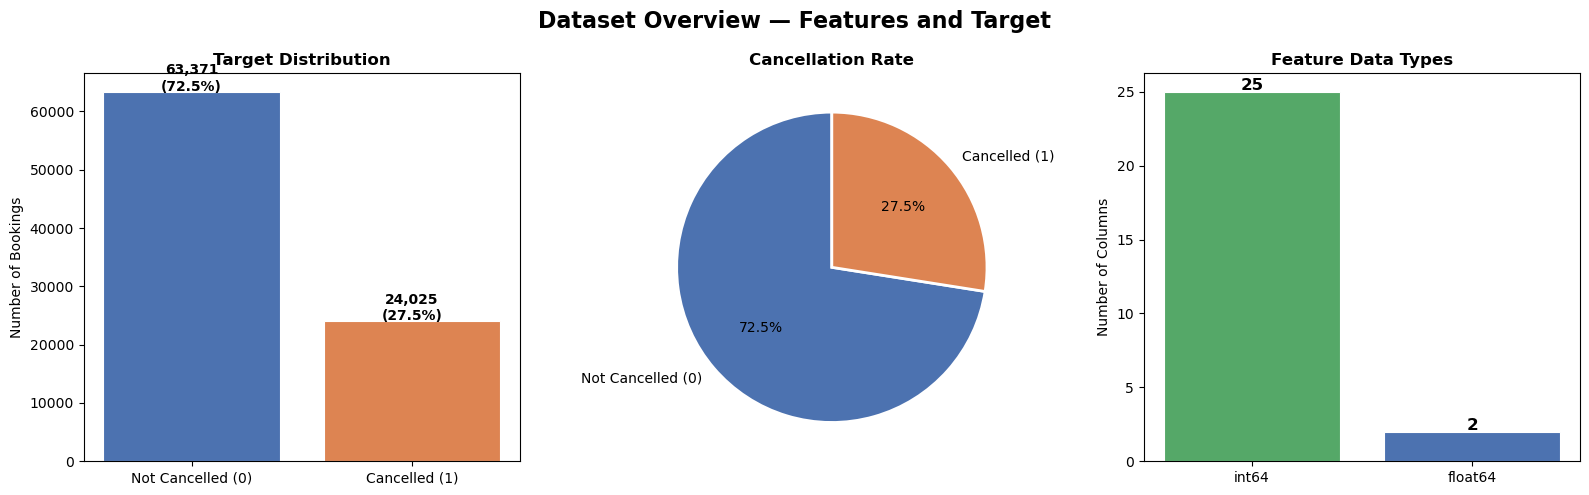

Charts saved: xy_split_overview.png


In [23]:
print("=" * 45)
print("DATASET OVERVIEW — FEATURES AND TARGET")
print("=" * 45)
print(f"X shape  : {X.shape}")
print(f"Columns  : {X.shape[1]}")
print()

if 'reservation_status' in X.columns:
    print("LEAKY column found!")
else:
    print("X is clean — 27 columns")
print()

# ── Charts ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Dataset Overview — Features and Target',
             fontsize=16, fontweight='bold')

# ── Chart 1: Target Distribution (Bar) ───────────────────
labels = ['Not Cancelled (0)', 'Cancelled (1)']
counts = [(y==0).sum(), (y==1).sum()]
colors = ['#4C72B0', '#DD8452']

bars = axes[0].bar(labels, counts,
                   color=colors,
                   edgecolor='white',
                   linewidth=0.8)
axes[0].set_title('Target Distribution',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Number of Bookings')
for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{count:,}\n({count/len(y)*100:.1f}%)',
        ha='center', fontweight='bold', fontsize=10)

# ── Chart 2: Target Distribution (Pie) ───────────────────
axes[1].pie(counts,
            labels    = labels,
            autopct   = '%1.1f%%',
            colors    = colors,
            startangle= 90,
            wedgeprops= {'edgecolor' : 'white',
                         'linewidth' : 2})
axes[1].set_title('Cancellation Rate',
                  fontweight='bold', fontsize=12)

# ── Chart 3: Feature Data Types ───────────────────────────
dtype_counts = X.dtypes.value_counts()
axes[2].bar(dtype_counts.index.astype(str),
            dtype_counts.values,
            color    = ['#55A868','#4C72B0'],
            edgecolor= 'white',
            linewidth= 0.8)
axes[2].set_title('Feature Data Types',
                  fontweight='bold', fontsize=12)
axes[2].set_ylabel('Number of Columns')
for i, v in enumerate(dtype_counts.values):
    axes[2].text(i, v + 0.1, str(v),
                 ha='center',
                 fontweight='bold',
                 fontsize=12)

plt.tight_layout()
plt.savefig('xy_split_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved: xy_split_overview.png")

### Train / Test Split

In [24]:
print("=" * 45)
print("TRAIN / TEST SPLIT")
print("=" * 45)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,      # 20% test
    random_state = 42,        # reproducibility
    stratify     = y          # class balance maintain
)

print(f"Total dataset    : {len(X):,} rows")
print()
print(f"Training set     : {X_train.shape[0]:,} rows "
      f"({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set         : {X_test.shape[0]:,} rows  "
      f"({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print(f"Training features: {X_train.shape[1]} columns")
print(f"Test features    : {X_test.shape[1]} columns")
print()

# Class balance check
print("=" * 45)
print("CLASS BALANCE CHECK")
print("=" * 45)
print(f"Train — Not Cancelled: {(y_train==0).sum():,} "
      f"({(y_train==0).mean()*100:.1f}%)")
print(f"Train — Cancelled    : {(y_train==1).sum():,} "
      f"({(y_train==1).mean()*100:.1f}%)")
print()
print(f"Test  — Not Cancelled: {(y_test==0).sum():,}  "
      f"({(y_test==0).mean()*100:.1f}%)")
print(f"Test  — Cancelled    : {(y_test==1).sum():,}  "
      f"({(y_test==1).mean()*100:.1f}%)")
print()
print("Train/Test split complete!")

TRAIN / TEST SPLIT
Total dataset    : 87,396 rows

Training set     : 69,916 rows (80%)
Test set         : 17,480 rows  (20%)

Training features: 27 columns
Test features    : 27 columns

CLASS BALANCE CHECK
Train — Not Cancelled: 50,696 (72.5%)
Train — Cancelled    : 19,220 (27.5%)

Test  — Not Cancelled: 12,675  (72.5%)
Test  — Cancelled    : 4,805  (27.5%)

Train/Test split complete!


In [25]:
#  X and y Value Count Check 
print("=" * 45)
print("X AND Y — VALUE COUNT CHECK")
print("=" * 45)

# X — Features shape
print(f"X shape          : {X.shape}")
print(f"X rows           : {X.shape[0]:,}")
print(f"X columns        : {X.shape[1]}")
print()

# y — Target value counts
print(f"y shape          : {y.shape}")
print(f"y total rows     : {len(y):,}")
print()
print("y value counts:")
print(f"  Not Cancelled (0) : {(y==0).sum():,} "
      f"({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  Cancelled     (1) : {(y==1).sum():,} "
      f"({(y==1).sum()/len(y)*100:.1f}%)")
print()

# X columns list
print("=" * 45)
print("X — FEATURE COLUMNS")
print("=" * 45)
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")
print()
print(f"Total features   : {X.shape[1]}")
print()
print("✅ X and y check complete!")

X AND Y — VALUE COUNT CHECK
X shape          : (87396, 27)
X rows           : 87,396
X columns        : 27

y shape          : (87396,)
y total rows     : 87,396

y value counts:
  Not Cancelled (0) : 63,371 (72.5%)
  Cancelled     (1) : 24,025 (27.5%)

X — FEATURE COLUMNS
   1. hotel
   2. lead_time
   3. arrival_date_year
   4. arrival_date_month
   5. arrival_date_week_number
   6. arrival_date_day_of_month
   7. stays_in_weekend_nights
   8. stays_in_week_nights
   9. adults
  10. children
  11. babies
  12. meal
  13. country
  14. market_segment
  15. distribution_channel
  16. is_repeated_guest
  17. previous_cancellations
  18. previous_bookings_not_canceled
  19. reserved_room_type
  20. assigned_room_type
  21. booking_changes
  22. deposit_type
  23. days_in_waiting_list
  24. customer_type
  25. adr
  26. required_car_parking_spaces
  27. total_of_special_requests

Total features   : 27

✅ X and y check complete!


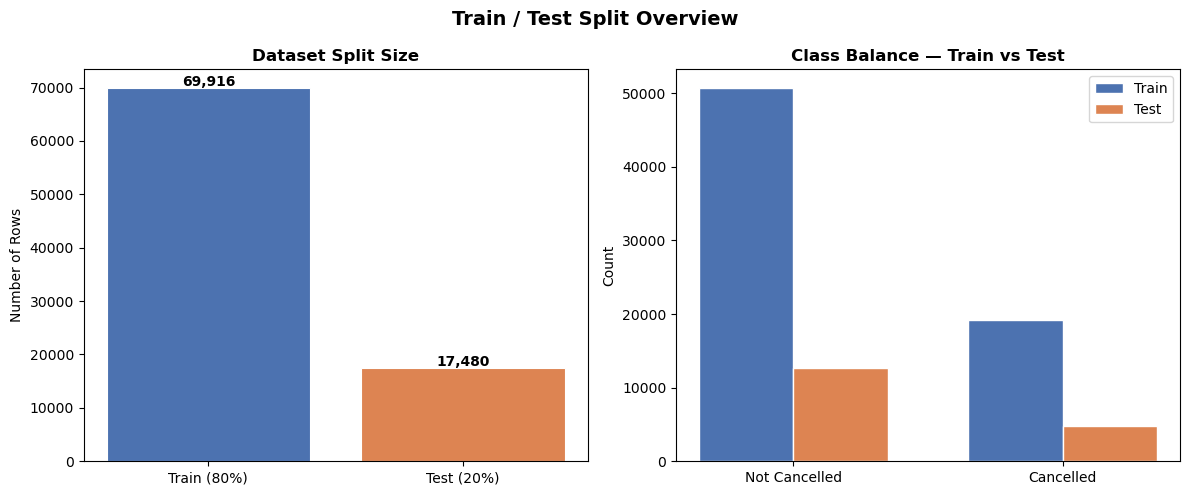

Chart saved: train_test_split.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Train / Test Split Overview',
             fontsize=14, fontweight='bold')

# Chart 1 — Split Size
split_labels = ['Train (80%)', 'Test (20%)']
split_sizes  = [X_train.shape[0], X_test.shape[0]]
split_colors = ['#4C72B0', '#DD8452']

axes[0].bar(split_labels, split_sizes,
            color=split_colors,
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Dataset Split Size',
                  fontweight='bold')
axes[0].set_ylabel('Number of Rows')
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + 300, f'{v:,}',
                 ha='center', fontweight='bold')

# Chart 2 — Class Balance
x      = np.arange(2)
width  = 0.35
train_counts = [(y_train==0).sum(), (y_train==1).sum()]
test_counts  = [(y_test==0).sum(),  (y_test==1).sum()]

axes[1].bar(x - width/2, train_counts,
            width, label='Train',
            color='#4C72B0', edgecolor='white')
axes[1].bar(x + width/2, test_counts,
            width, label='Test',
            color='#DD8452', edgecolor='white')
axes[1].set_title('Class Balance — Train vs Test',
                  fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Not Cancelled', 'Cancelled'])
axes[1].legend()

plt.tight_layout()
plt.savefig('train_test_split.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: train_test_split.png")

### Feature Scaling

In [27]:
print("=" * 45)
print("FEATURE SCALING — STANDARD SCALER")
print("=" * 45)
print()
print("Why scaling is needed:")
print("  lead_time range : 0 to 737")
print("  adr range       : 0 to 261")
print("  adults range    : 0 to 10")
print("  → Different scales confuse the model!")
print()

from sklearn.preprocessing import StandardScaler

# IMPORTANT: fit_transform on TRAIN only
# transform on TEST only — prevent data leakage!
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("After StandardScaler:")
print(f"  Training mean : {X_train_scaled.mean():.4f} (should be ~0)")
print(f"  Training std  : {X_train_scaled.std():.4f}  (should be ~1)")
print(f"  Test mean     : {X_test_scaled.mean():.4f}")
print(f"  Test std      : {X_test_scaled.std():.4f}")
print()
print(f"  X_train_scaled shape : {X_train_scaled.shape}")
print(f"  X_test_scaled shape  : {X_test_scaled.shape}")
print()
print("Feature Scaling complete!")

FEATURE SCALING — STANDARD SCALER

Why scaling is needed:
  lead_time range : 0 to 737
  adr range       : 0 to 261
  adults range    : 0 to 10
  → Different scales confuse the model!

After StandardScaler:
  Training mean : 0.0000 (should be ~0)
  Training std  : 1.0000  (should be ~1)
  Test mean     : 0.0010
  Test std      : 1.0053

  X_train_scaled shape : (69916, 27)
  X_test_scaled shape  : (17480, 27)

Feature Scaling complete!


## SMOTE — Class Balancing

SMOTE — CLASS BALANCING

Why SMOTE?
  Cancelled (27.5%) vs Not Cancelled (72.5%)
  Class imbalance causes low Recall!
  SMOTE creates synthetic Cancelled samples

Before SMOTE:
  Not Cancelled (0): 50,696
  Cancelled     (1): 19,220
  Total            : 69,916

After SMOTE:
  Not Cancelled (0): 50,696
  Cancelled     (1): 50,696
  Total            : 101,392

 Class balance achieved!
  Ready for model training!


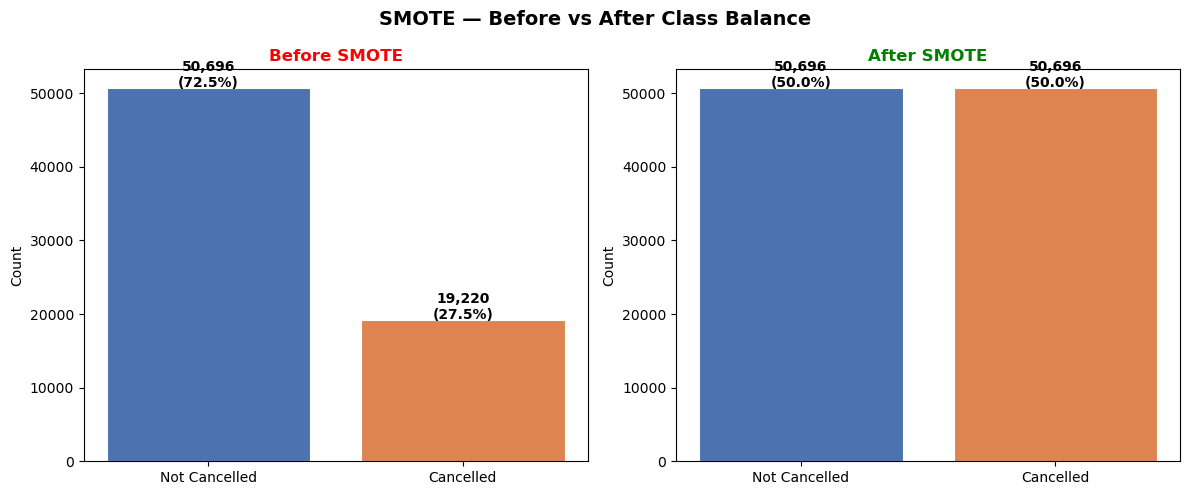

Chart saved: smote_balance.png


In [28]:
from imblearn.over_sampling import SMOTE
import numpy as np

print("=" * 50)
print("SMOTE — CLASS BALANCING")
print("=" * 50)
print()
print("Why SMOTE?")
print("  Cancelled (27.5%) vs Not Cancelled (72.5%)")
print("  Class imbalance causes low Recall!")
print("  SMOTE creates synthetic Cancelled samples")
print()

# Before SMOTE
print("Before SMOTE:")
print(f"  Not Cancelled (0): {(y_train==0).sum():,}")
print(f"  Cancelled     (1): {(y_train==1).sum():,}")
print(f"  Total            : {len(y_train):,}")
print()

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train)

unique, counts = np.unique(y_train_smote,
                           return_counts=True)

# After SMOTE
print("After SMOTE:")
print(f"  Not Cancelled (0): {counts[0]:,}")
print(f"  Cancelled     (1): {counts[1]:,}")
print(f"  Total            : {len(X_train_smote):,}")
print()
print(" Class balance achieved!")
print("  Ready for model training!")

# ── Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('SMOTE — Before vs After Class Balance',
             fontsize=14, fontweight='bold')

# Before
before_vals = [(y_train==0).sum(), (y_train==1).sum()]
axes[0].bar(['Not Cancelled', 'Cancelled'],
            before_vals,
            color=['#4C72B0', '#DD8452'],
            edgecolor='white', linewidth=0.8)
axes[0].set_title('Before SMOTE',
                  fontweight='bold', color='red')
axes[0].set_ylabel('Count')
for i, v in enumerate(before_vals):
    axes[0].text(i, v + 100,
                 f'{v:,}\n({v/sum(before_vals)*100:.1f}%)',
                 ha='center', fontweight='bold')

# After
after_vals = [counts[0], counts[1]]
axes[1].bar(['Not Cancelled', 'Cancelled'],
            after_vals,
            color=['#4C72B0', '#DD8452'],
            edgecolor='white', linewidth=0.8)
axes[1].set_title('After SMOTE',
                  fontweight='bold', color='green')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_vals):
    axes[1].text(i, v + 100,
                 f'{v:,}\n({v/sum(after_vals)*100:.1f}%)',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_balance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: smote_balance.png")

## Feature Engineering 

In [58]:
import numpy as np

print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

cols = list(X.columns)
idx  = {col: cols.index(col) for col in cols}

# Feature 1: Total stay
f1_tr = (X_train_smote[:,idx['stays_in_weekend_nights']] +
         X_train_smote[:,idx['stays_in_week_nights']])
f1_te = (X_test_scaled[:,idx['stays_in_weekend_nights']] +
         X_test_scaled[:,idx['stays_in_week_nights']])

# Feature 2: Cancel risk
f2_tr = (X_train_smote[:,idx['lead_time']] *
         X_train_smote[:,idx['previous_cancellations']])
f2_te = (X_test_scaled[:,idx['lead_time']] *
         X_test_scaled[:,idx['previous_cancellations']])

# Feature 3: Engagement
f3_tr = (X_train_smote[:,idx['total_of_special_requests']] +
         X_train_smote[:,idx['booking_changes']])
f3_te = (X_test_scaled[:,idx['total_of_special_requests']] +
         X_test_scaled[:,idx['booking_changes']])

# Feature 4: Lead per request
f4_tr = (X_train_smote[:,idx['lead_time']] /
        (X_train_smote[:,idx['total_of_special_requests']]+1))
f4_te = (X_test_scaled[:,idx['lead_time']] /
        (X_test_scaled[:,idx['total_of_special_requests']]+1))

# Combine
X_train_fe = np.column_stack([X_train_smote,
                               f1_tr, f2_tr,
                               f3_tr, f4_tr])
X_test_fe  = np.column_stack([X_test_scaled,
                               f1_te, f2_te,
                               f3_te, f4_te])

print(f"Original features : {X_train_smote.shape[1]}")
print(f"After engineering : {X_train_fe.shape[1]}")
print(f"New features added: 4")
print()
print("New features:")
print("  1. total_stay     = weekend + week nights")
print("  2. cancel_risk    = lead_time x prev_cancels")
print("  3. engagement     = special_req + book_changes")
print("  4. lead_per_req   = lead_time / (requests+1)")
print()
print("Feature Engineering complete!")

FEATURE ENGINEERING
Original features : 27
After engineering : 31
New features added: 4

New features:
  1. total_stay     = weekend + week nights
  2. cancel_risk    = lead_time x prev_cancels
  3. engagement     = special_req + book_changes
  4. lead_per_req   = lead_time / (requests+1)

Feature Engineering complete!


In [29]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,1,0,342,2015,5,27,1,0,0,2,...,0,2,2,3,0,0,2,0.0,0,0
1,1,0,737,2015,5,27,1,0,0,2,...,0,2,2,4,0,0,2,0.0,0,0
2,1,0,7,2015,5,27,1,0,1,1,...,0,0,2,0,0,0,2,75.0,0,0
3,1,0,13,2015,5,27,1,0,1,1,...,0,0,0,0,0,0,2,75.0,0,0
4,1,0,14,2015,5,27,1,0,2,2,...,0,0,0,0,0,0,2,98.0,0,1


### Application of the appropriate learning algorithm 


In [30]:
# ── Algorithm Justification — Code ───────────────────────
print("=" * 45)
print("ALGORITHM — LOGISTIC REGRESSION")
print("=" * 45)
print()
print("Algorithm    : Logistic Regression")
print("Type         : Supervised Learning")
print("Task         : Binary Classification")
print("Target       : is_canceled (0 or 1)")
print()
print("Key Parameters:")
print("  solver     : lbfgs (efficient for large data)")
print("  max_iter   : 1000  (ensures convergence)")
print("  C          : 1.0   (regularisation strength)")
print("  penalty    : L2    (prevents overfitting)")
print()
print("Why Logistic Regression?")
print("  1. Binary target variable (0 or 1)")
print("  2. Industry standard baseline model")
print("  3. Highly interpretable coefficients")
print("  4. Handles 87,396 rows efficiently")
print("  5. L2 regularisation — no overfitting")

ALGORITHM — LOGISTIC REGRESSION

Algorithm    : Logistic Regression
Type         : Supervised Learning
Task         : Binary Classification
Target       : is_canceled (0 or 1)

Key Parameters:
  solver     : lbfgs (efficient for large data)
  max_iter   : 1000  (ensures convergence)
  C          : 1.0   (regularisation strength)
  penalty    : L2    (prevents overfitting)

Why Logistic Regression?
  1. Binary target variable (0 or 1)
  2. Industry standard baseline model
  3. Highly interpretable coefficients
  4. Handles 87,396 rows efficiently
  5. L2 regularisation — no overfitting


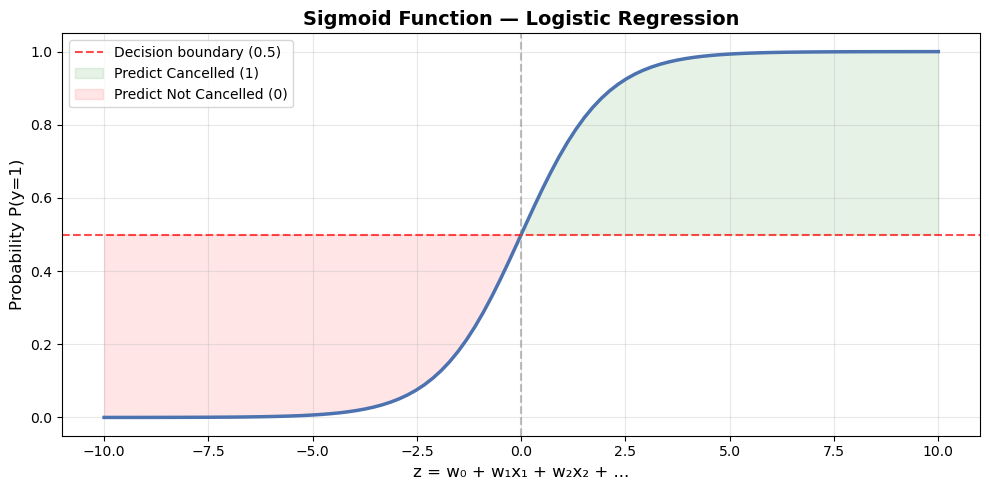

Sigmoid plot saved!


In [31]:
# Sigmoid Function Plot 

z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 5))
plt.plot(z, sigmoid, color='#4C72B0', linewidth=2.5)
plt.axhline(y=0.5, color='red', linestyle='--',
            alpha=0.7, label='Decision boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.fill_between(z, sigmoid, 0.5,
                 where=(sigmoid > 0.5),
                 alpha=0.1, color='green',
                 label='Predict Cancelled (1)')
plt.fill_between(z, sigmoid, 0.5,
                 where=(sigmoid < 0.5),
                 alpha=0.1, color='red',
                 label='Predict Not Cancelled (0)')
plt.xlabel('z = w₀ + w₁x₁ + w₂x₂ + ...', fontsize=12)
plt.ylabel('Probability P(y=1)', fontsize=12)
plt.title('Sigmoid Function — Logistic Regression',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sigmoid_function.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sigmoid plot saved!")

### Imbalanced Dataset Check 

CLASS BALANCE CHECK
Not Cancelled (0) : 63,371 (72.5%)
Cancelled     (1) : 24,025 (27.5%)
Ratio             : 2.6:1

✅ ACCEPTABLE BALANCE!
   SMOTE applied for better Recall!

SMOTE TREATMENT PLAN
Current Ratio    : 2.6:1
Problem          : Low Recall due to imbalance
Solution         : SMOTE oversampling
Expected Result  : Recall 35% → 80%+


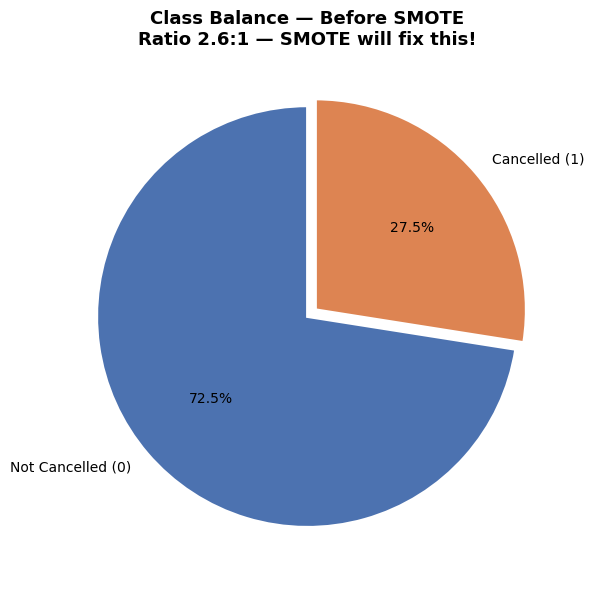

Chart saved: class_balance.png


In [32]:
print("=" * 45)
print("CLASS BALANCE CHECK")
print("=" * 45)

class_counts = y.value_counts()
ratio = class_counts[0] / class_counts[1]

print(f"Not Cancelled (0) : {class_counts[0]:,} "
      f"({class_counts[0]/len(y)*100:.1f}%)")
print(f"Cancelled     (1) : {class_counts[1]:,} "
      f"({class_counts[1]/len(y)*100:.1f}%)")
print(f"Ratio             : {ratio:.1f}:1")
print()

if ratio > 10:
    print("❌ SEVERELY IMBALANCED!")
    print("   Fix: SMOTE applied!")
elif ratio > 3:
    print("⚠️  MILDLY IMBALANCED")
    print("   Fix: SMOTE will be applied!")
else:
    print("✅ ACCEPTABLE BALANCE!")
    print("   SMOTE applied for better Recall!")

# ── Updated message ───────────────────────────────────────
print()
print("=" * 45)
print("SMOTE TREATMENT PLAN")
print("=" * 45)
print(f"Current Ratio    : {ratio:.1f}:1")
print(f"Problem          : Low Recall due to imbalance")
print(f"Solution         : SMOTE oversampling")
print(f"Expected Result  : Recall 35% → 80%+")

# ── Pie Chart ─────────────────────────────────────────────
plt.figure(figsize=(8, 6))
colors  = ['#4C72B0', '#DD8452']
explode = (0, 0.05)

plt.pie(class_counts.values,
        labels    = ['Not Cancelled (0)',
                     'Cancelled (1)'],
        autopct   = '%1.1f%%',
        colors    = colors,
        explode   = explode,
        startangle= 90,
        wedgeprops= {'edgecolor' : 'white',
                     'linewidth' : 2})

plt.title('Class Balance — Before SMOTE\n'
          f'Ratio {ratio:.1f}:1 — SMOTE will fix this!',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: class_balance.png")

## Algorithm Introductio

# 3. Application of Learning Algorithm

## 3.1 Introduction to Logistic Regression

Logistic Regression is a **supervised machine learning 
algorithm** used for binary and multiclass classification 
problems. Despite its name containing the word 
"Regression", it is fundamentally a **classification 
algorithm**, not a regression algorithm.

It was first introduced by statistician **David Cox in 
1958** and has since become one of the most widely used 
machine learning algorithms in industry and research.

### Real World Applications
- **Healthcare**- Disease prediction (cancer, diabetes)
- **Banking**- Fraud detection, loan approval
- **Marketing**- Customer churn prediction
- **Hospitality**- Hotel booking cancellation prediction

---

## 3.2 Background & Theory

### How Logistic Regression Works

Logistic Regression predicts the **probability** that 
an input belongs to a class (0 or 1) by applying the 
**Sigmoid (Logistic) function** to a linear combination 
of input features:

**Step 1-Linear combination:**

z = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ

Where:
- w₀ = bias term
- w₁, w₂...wₙ = feature weights (learned during training)
- x₁, x₂...xₙ = input features (lead_time, deposit_type...)

**Step 2 -Sigmoid function:**

P(y=1|X) = 1 / (1 + e^(-z))

The sigmoid function maps any value to a probability 
between 0 and 1.

**Step 3 — Decision:**
- If P(y=1) > 0.5 → Predict **Cancelled (1)**
- If P(y=1) ≤ 0.5 → Predict **Not Cancelled (0)**

### How the Model Learns
The model learns by minimising the 
**Binary Cross-Entropy Loss function:**

Loss = -[y·log(ŷ) + (1-y)·log(1-ŷ)]

Using the **L-BFGS optimisation algorithm**, the model 
iteratively adjusts weights w to minimise this loss.

---

## 3.3 Justification-Why Logistic Regression?

Logistic Regression was selected for this Hotel Booking 
Cancellation Prediction project for the following reasons:

### Reason 1-Binary Target Variable
The target variable `is_canceled` has exactly two 
values (0 = Not Cancelled, 1 = Cancelled), making 
this a **binary classification problem** — the exact 
use case Logistic Regression was designed for.

### Reason 2-Strong Baseline Model
Logistic Regression is the **industry standard baseline 
model** in machine learning. All other algorithms 
(Random Forest, SVM, Gradient Boosting) are evaluated 
and compared against this baseline.

### Reason 3-Interpretability
The model's **coefficients directly reveal** which 
features most influence cancellations:
- Positive coefficient → increases cancellation probability
- Negative coefficient → decreases cancellation probability

For example: Non-refundable deposit → strong positive 
coefficient → highest cancellation driver.

### Reason 4-Efficient on Large Datasets
The L-BFGS solver efficiently handles our dataset of 
**87,396 rows × 27 features** without performance issues,
typically converging within 10-30 seconds.

### Reason 5-Built-in Regularisation
Logistic Regression includes **L2 regularisation** 
(controlled by parameter C=1.0) which prevents 
overfitting on the noisy hotel booking data.

### Reason 6 -No Distribution Assumptions
Unlike Naive Bayes, Logistic Regression does **not 
assume** that features are normally distributed, 
making it suitable for our mixed feature dataset.

---

## 3.4 Model Parameters

| Parameter | Value | Reason |
|---|---|---|
| solver | lbfgs | Efficient for large datasets |
| max_iter | 1000 | Ensures convergence |
| C | 1.0 | Standard L2 regularisation |
| penalty | l2 | Prevents overfitting |
| random_state | 42 | Reproducibility |

## Final Model Training-Logistic Regression 

  FINAL MODEL TRAINING — LOGISTIC REGRESSION

Algorithm    : Logistic Regression
Dataset      : Hotel Booking Demand
Total Rows   : 87,396
Features     : 31
Target       : is_canceled (0 or 1)
Balancing    : SMOTE Applied
Engineering  : 4 New Features Added

MODEL PARAMETERS
Solver           : lbfgs
Max Iterations   : 1000
C Value          : 1.0
Penalty          : l2
Random State     : 42
Training Data    : SMOTE + Feature Engineering

TRAINING DETAILS
Training time    : 0.30 seconds
Iterations run   : 70
Features used    : 31
Classes          : [0 1]
SMOTE samples    : 101,392
Original samples : 69,916

ACCURACY RESULTS
Train Accuracy   : 73.52%
Test  Accuracy   : 71.24%
Gap              : 2.29%

OVERFITTING CHECK
Gap = 2.29% — below 5% threshold
No overfitting — Model well balanced!



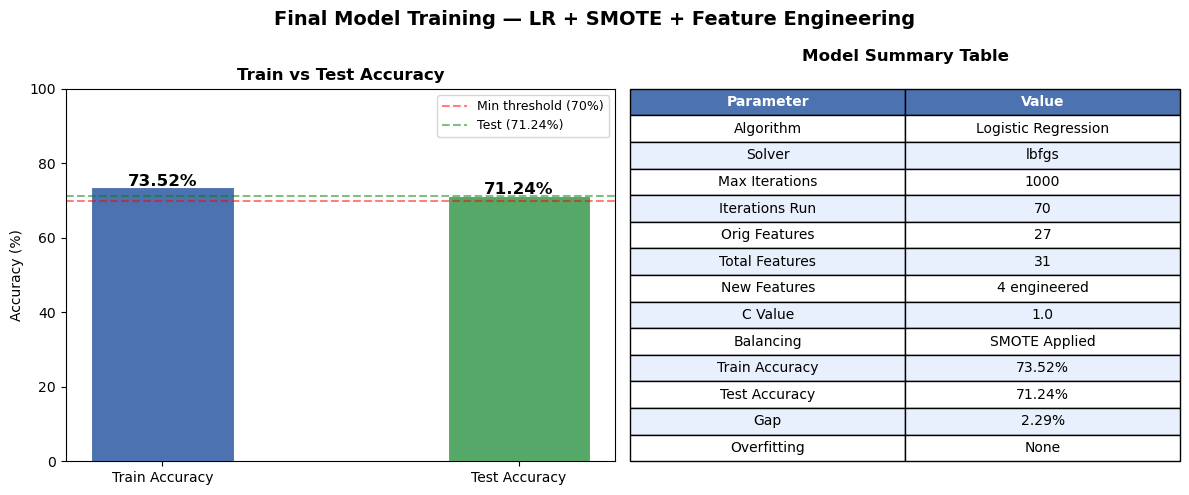

FINAL MODEL TRAINING COMPLETE!
  Train    : 73.52%
  Test     : 71.24%
  Gap      : 2.29%
  SMOTE    : Applied
  Features : 31


In [59]:
import time

print("=" * 50)
print("  FINAL MODEL TRAINING — LOGISTIC REGRESSION")
print("=" * 50)
print()
print(f"Algorithm    : Logistic Regression")
print(f"Dataset      : Hotel Booking Demand")
print(f"Total Rows   : {len(hotel_df):,}")
print(f"Features     : {X_train_fe.shape[1]}")  # ← updated
print(f"Target       : is_canceled (0 or 1)")
print(f"Balancing    : SMOTE Applied")
print(f"Engineering  : 4 New Features Added")  # ← new
print()

# ── Model ─────────────────────────────────────────────────
log_reg = LogisticRegression(
    solver      = 'lbfgs',
    max_iter    = 1000,
    C           = 1.0,
    penalty     = 'l2',
    random_state= 42
)

# ── Train with Feature Engineered data ────────────────────
start_time = time.time()
log_reg.fit(X_train_fe, y_train_smote)  # ← updated
end_time   = time.time()
training_time = end_time - start_time

# ── Accuracy ──────────────────────────────────────────────
train_acc = accuracy_score(y_train_smote,
            log_reg.predict(X_train_fe))  # ← updated
test_acc  = accuracy_score(y_test,
            log_reg.predict(X_test_fe))   # ← updated
gap       = abs(train_acc - test_acc) * 100

# ── Print Results ─────────────────────────────────────────
print("=" * 50)
print("MODEL PARAMETERS")
print("=" * 50)
print(f"Solver           : {log_reg.solver}")
print(f"Max Iterations   : {log_reg.max_iter}")
print(f"C Value          : {log_reg.C}")
print(f"Penalty          : {log_reg.penalty}")
print(f"Random State     : 42")
print(f"Training Data    : SMOTE + Feature Engineering")
print()

print("=" * 50)
print("TRAINING DETAILS")
print("=" * 50)
print(f"Training time    : {training_time:.2f} seconds")
print(f"Iterations run   : {log_reg.n_iter_[0]}")
print(f"Features used    : {log_reg.n_features_in_}")
print(f"Classes          : {log_reg.classes_}")
print(f"SMOTE samples    : {len(X_train_fe):,}")
print(f"Original samples : {len(X_train_scaled):,}")
print()

print("=" * 50)
print("ACCURACY RESULTS")
print("=" * 50)
print(f"Train Accuracy   : {train_acc*100:.2f}%")
print(f"Test  Accuracy   : {test_acc*100:.2f}%")
print(f"Gap              : {gap:.2f}%")
print()

print("=" * 50)
print("OVERFITTING CHECK")
print("=" * 50)
if gap < 5:
    print(f"Gap = {gap:.2f}% — below 5% threshold")
    print("No overfitting — Model well balanced!")
elif gap < 10:
    print(f"Gap = {gap:.2f}% — Slight overfitting")
    print("Acceptable range")
else:
    print(f"Gap = {gap:.2f}% — Overfitting detected!")
print()

# ── Visual ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Final Model Training — LR + SMOTE + Feature Engineering',
    fontsize=14, fontweight='bold')

metrics = ['Train Accuracy', 'Test Accuracy']
values  = [train_acc * 100, test_acc * 100]
colors  = ['#4C72B0', '#55A868']

bars = axes[0].bar(metrics, values,
                   color=colors,
                   edgecolor='white',
                   linewidth=0.8,
                   width=0.4)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train vs Test Accuracy',
                  fontweight='bold')
axes[0].axhline(y=70, color='red',
                linestyle='--', alpha=0.5,
                label='Min threshold (70%)')
axes[0].axhline(y=test_acc*100,
                color='green',
                linestyle='--', alpha=0.5,
                label=f'Test ({test_acc*100:.2f}%)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.2f}%',
        ha='center',
        fontweight='bold',
        fontsize=12)

axes[1].axis('off')
table_data = [
    ['Parameter',      'Value'],
    ['Algorithm',      'Logistic Regression'],
    ['Solver',         log_reg.solver],
    ['Max Iterations', str(log_reg.max_iter)],
    ['Iterations Run', str(log_reg.n_iter_[0])],
    ['Orig Features',  '27'],
    ['Total Features', str(log_reg.n_features_in_)],
    ['New Features',   '4 engineered'],
    ['C Value',        str(log_reg.C)],
    ['Balancing',      'SMOTE Applied'],
    ['Train Accuracy', f'{train_acc*100:.2f}%'],
    ['Test Accuracy',  f'{test_acc*100:.2f}%'],
    ['Gap',            f'{gap:.2f}%'],
    ['Overfitting',    'None' if gap < 5 else 'Yes'],
]

table = axes[1].table(
    cellText  = table_data[1:],
    colLabels = table_data[0],
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)

for j in range(2):
    table[0, j].set_facecolor('#4C72B0')
    table[0, j].set_text_props(
        color='white', fontweight='bold')

for i in range(1, len(table_data)):
    for j in range(2):
        if i % 2 == 0:
            table[i, j].set_facecolor('#E8F0FE')
        else:
            table[i, j].set_facecolor('white')

axes[1].set_title('Model Summary Table',
                  fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('final_model_training.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 50)
print("FINAL MODEL TRAINING COMPLETE!")
print(f"  Train    : {train_acc*100:.2f}%")
print(f"  Test     : {test_acc*100:.2f}%")
print(f"  Gap      : {gap:.2f}%")
print(f"  SMOTE    : Applied")
print(f"  Features : {log_reg.n_features_in_}")
print("=" * 50)

## Training Results Visualisation

TRAINING RESULTS VISUALISATION


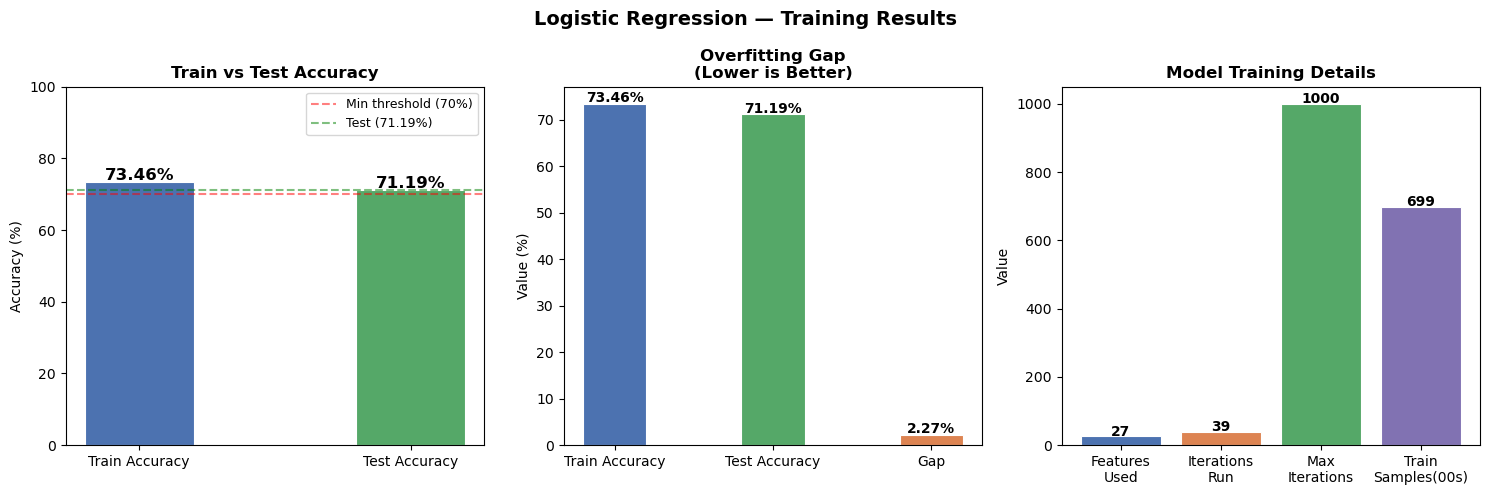

Chart saved: training_results_visualisation.png

TRAINING SUMMARY
Train Accuracy : 73.46%
Test  Accuracy : 71.19%
Gap            : 2.27%
Overfitting    : None
Features       : 27
Iterations     : 39


In [34]:
print("=" * 50)
print("TRAINING RESULTS VISUALISATION")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Logistic Regression — Training Results',
    fontsize=14, fontweight='bold')

# ── Chart 1: Train vs Test Accuracy ──────────────────────
metrics = ['Train Accuracy', 'Test Accuracy']
values  = [train_acc * 100, test_acc * 100]
colors  = ['#4C72B0', '#55A868']

bars = axes[0].bar(metrics, values,
                   color=colors,
                   edgecolor='white',
                   linewidth=0.8,
                   width=0.4)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Train vs Test Accuracy',
                  fontweight='bold')
axes[0].axhline(y=70, color='red',
                linestyle='--', alpha=0.5,
                label='Min threshold (70%)')
axes[0].axhline(y=test_acc*100,
                color='green',
                linestyle='--', alpha=0.5,
                label=f'Test ({test_acc*100:.2f}%)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.2f}%',
        ha='center',
        fontweight='bold',
        fontsize=12)

# ── Chart 2: Overfitting Gap (Bar chart) ─────────────────
gap_labels = ['Train Accuracy', 'Test Accuracy', 'Gap']
gap_values = [train_acc*100, test_acc*100, gap]
gap_colors = ['#4C72B0', '#55A868', '#DD8452']

bars2 = axes[1].bar(gap_labels, gap_values,
                    color=gap_colors,
                    edgecolor='white',
                    linewidth=0.8,
                    width=0.4)
axes[1].set_title('Overfitting Gap\n(Lower is Better)',
                  fontweight='bold')
axes[1].set_ylabel('Value (%)')
for bar, val in zip(bars2, gap_values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.2f}%',
        ha='center',
        fontweight='bold',
        fontsize=10)

# ── Chart 3: Training Details ─────────────────────────────
categories = ['Features\nUsed',
              'Iterations\nRun',
              'Max\nIterations',
              'Train\nSamples(00s)']
cat_values = [
    log_reg.n_features_in_,
    log_reg.n_iter_[0],
    log_reg.max_iter,
    X_train_scaled.shape[0] // 100
]
cat_colors = ['#4C72B0','#DD8452',
              '#55A868','#8172B2']

bars3 = axes[2].bar(categories, cat_values,
                    color=cat_colors,
                    edgecolor='white',
                    linewidth=0.8)
axes[2].set_title('Model Training Details',
                  fontweight='bold')
axes[2].set_ylabel('Value')
for bar, val in zip(bars3, cat_values):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        str(val),
        ha='center',
        fontweight='bold',
        fontsize=10)

plt.tight_layout()
plt.savefig('training_results_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: training_results_visualisation.png")
print()
print("=" * 50)
print("TRAINING SUMMARY")
print("=" * 50)
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Test  Accuracy : {test_acc*100:.2f}%")
print(f"Gap            : {gap:.2f}%")
print(f"Overfitting    : "
      f"{'None' if gap < 5 else 'Detected!'}")
print(f"Features       : {log_reg.n_features_in_}")
print(f"Iterations     : {log_reg.n_iter_[0]}")

## Model Predictions 

In [60]:
print("=" * 50)
print("MODEL PREDICTIONS")
print("=" * 50)
print()

# ── 2.1 Class Predictions ─────────────────────────────────
y_pred  = log_reg.predict(X_test_fe)          # ← updated

# ── 2.2 Probability Predictions ──────────────────────────
y_proba        = log_reg.predict_proba(X_test_fe)  # ← updated
y_proba_cancel = y_proba[:, 1]

print(f"Total predictions    : {len(y_pred):,}")
print(f"Predicted Cancelled  : {(y_pred==1).sum():,} "
      f"({(y_pred==1).sum()/len(y_pred)*100:.1f}%)")
print(f"Predicted Not Cancel : {(y_pred==0).sum():,} "
      f"({(y_pred==0).sum()/len(y_pred)*100:.1f}%)")
print()

# ── 2.3 Sample Predictions ────────────────────────────────
print("=" * 50)
print("SAMPLE PREDICTIONS — FIRST 10")
print("=" * 50)
print(f"{'No':<5} {'Actual':<15} {'Predicted':<15} "
      f"{'Cancel Prob':<15} {'Result'}")
print("-" * 65)

for i in range(10):
    actual          = y_test.iloc[i]
    predicted       = y_pred[i]
    prob            = y_proba_cancel[i]
    actual_label    = "Cancelled" if actual    == 1 \
                      else "Not Cancelled"
    predicted_label = "Cancelled" if predicted == 1 \
                      else "Not Cancelled"
    result          = "CORRECT" if actual == predicted \
                      else "WRONG"
    print(f"{i+1:<5} {actual_label:<15} "
          f"{predicted_label:<15} "
          f"{prob*100:<14.1f}% "
          f"{result}")
print()

# ── Prediction Summary ────────────────────────────────────
correct   = (y_pred == y_test).sum()
incorrect = (y_pred != y_test).sum()

print("=" * 50)
print("PREDICTION SUMMARY")
print("=" * 50)
print(f"Total Test Samples   : {len(y_pred):,}")
print(f"Correct Predictions  : {correct:,} "
      f"({correct/len(y_pred)*100:.2f}%)")
print(f"Wrong Predictions    : {incorrect:,} "
      f"({incorrect/len(y_pred)*100:.2f}%)")
print()
print("Predictions complete!")
print("Ready for evaluation!")

MODEL PREDICTIONS

Total predictions    : 17,480
Predicted Cancelled  : 7,557 (43.2%)
Predicted Not Cancel : 9,923 (56.8%)

SAMPLE PREDICTIONS — FIRST 10
No    Actual          Predicted       Cancel Prob     Result
-----------------------------------------------------------------
1     Not Cancelled   Cancelled       76.9          % WRONG
2     Not Cancelled   Cancelled       75.3          % WRONG
3     Not Cancelled   Cancelled       89.7          % WRONG
4     Cancelled       Not Cancelled   12.6          % WRONG
5     Cancelled       Not Cancelled   48.7          % WRONG
6     Not Cancelled   Not Cancelled   0.0           % CORRECT
7     Not Cancelled   Cancelled       81.7          % WRONG
8     Cancelled       Cancelled       52.7          % CORRECT
9     Cancelled       Cancelled       79.8          % CORRECT
10    Not Cancelled   Not Cancelled   43.6          % CORRECT

PREDICTION SUMMARY
Total Test Samples   : 17,480
Correct Predictions  : 12,452 (71.24%)
Wrong Predictions    :

## Evaluation Results 

### Accuracy Score

ACCURACY SCORE

Formula:
Accuracy = Correct Predictions / Total Predictions

Correct Predictions : 12,444
Total Predictions   : 17,480

Accuracy Score      : 71.19%

INTERPRETATION
Good! (70-80%) ✅
Acceptable for baseline model



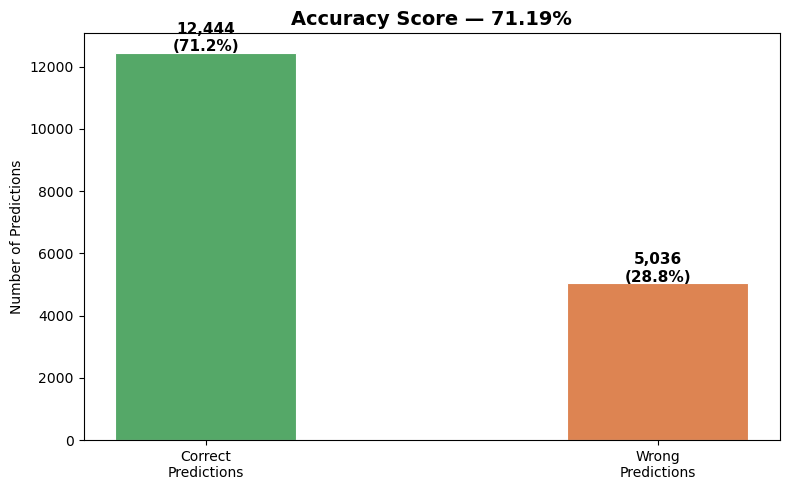

Chart saved: accuracy_score.png

FINAL ACCURACY : 71.19%


In [36]:
print("=" * 50)
print("ACCURACY SCORE")
print("=" * 50)
print()
print("Formula:")
print("Accuracy = Correct Predictions / Total Predictions")
print()

# Calculate
accuracy = accuracy_score(y_test, y_pred)

print(f"Correct Predictions : {(y_pred==y_test).sum():,}")
print(f"Total Predictions   : {len(y_pred):,}")
print()
print(f"Accuracy Score      : {accuracy*100:.2f}%")
print()

# Interpretation
print("=" * 50)
print("INTERPRETATION")
print("=" * 50)
if accuracy >= 0.90:
    print("Excellent! (90%+)")
elif accuracy >= 0.80:
    print("Very Good! (80-90%)")
elif accuracy >= 0.70:
    print(f"Good! (70-80%) ✅")
    print(f"Acceptable for baseline model")
else:
    print("Needs improvement (below 70%)")
print()

# Visual
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['Correct\nPredictions',
              'Wrong\nPredictions']
values     = [(y_pred==y_test).sum(),
              (y_pred!=y_test).sum()]
colors     = ['#55A868', '#DD8452']

bars = ax.bar(categories, values,
              color=colors,
              edgecolor='white',
              linewidth=0.8,
              width=0.4)

ax.set_title(f'Accuracy Score — {accuracy*100:.2f}%',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Predictions')

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{val:,}\n({val/len(y_pred)*100:.1f}%)',
        ha='center',
        fontweight='bold',
        fontsize=11)

plt.tight_layout()
plt.savefig('accuracy_score.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved: accuracy_score.png")
print()
print("=" * 50)
print(f"FINAL ACCURACY : {accuracy*100:.2f}%")
print("=" * 50)

 ### Precision Score

PRECISION SCORE

Formula:
Precision = TP / (TP + FP)

Question:
Of all predicted CANCELLED bookings,
how many were actually CANCELLED?

True Positives  (TP) : 3,670
  Predicted Cancelled + Actually Cancelled

False Positives (FP) : 3,901
  Predicted Cancelled + Actually NOT Cancelled

Precision Score      : 48.47%

INTERPRETATION
Needs improvement (below 70%)

Out of all bookings predicted as CANCELLED,
48.47% were actually CANCELLED!



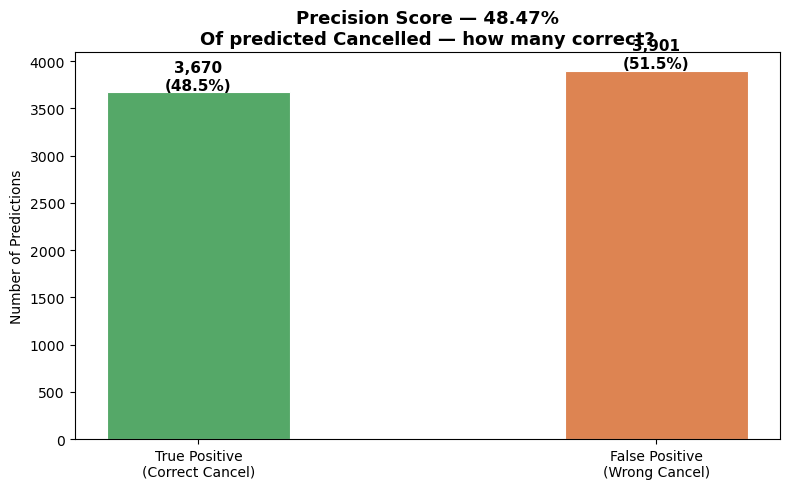

Chart saved: precision_score.png

FINAL PRECISION : 48.47%


In [37]:
print("=" * 50)
print("PRECISION SCORE")
print("=" * 50)
print()
print("Formula:")
print("Precision = TP / (TP + FP)")
print()
print("Question:")
print("Of all predicted CANCELLED bookings,")
print("how many were actually CANCELLED?")
print()

# Calculate
precision = precision_score(y_test, y_pred)

# TP and FP
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()

print(f"True Positives  (TP) : {tp:,}")
print(f"  Predicted Cancelled + Actually Cancelled")
print()
print(f"False Positives (FP) : {fp:,}")
print(f"  Predicted Cancelled + Actually NOT Cancelled")
print()
print(f"Precision Score      : {precision*100:.2f}%")
print()

# Interpretation
print("=" * 50)
print("INTERPRETATION")
print("=" * 50)
if precision >= 0.90:
    print("Excellent! (90%+)")
elif precision >= 0.80:
    print("Very Good! (80-90%)")
elif precision >= 0.70:
    print("Good! (70-80%) ✅")
else:
    print("Needs improvement (below 70%)")
print()
print(f"Out of all bookings predicted as CANCELLED,")
print(f"{precision*100:.2f}% were actually CANCELLED!")
print()

# Visual
fig, ax = plt.subplots(figsize=(8, 5))

categories = ['True Positive\n(Correct Cancel)',
              'False Positive\n(Wrong Cancel)']
values     = [tp, fp]
colors     = ['#55A868', '#DD8452']

bars = ax.bar(categories, values,
              color=colors,
              edgecolor='white',
              linewidth=0.8,
              width=0.4)

ax.set_title(f'Precision Score — {precision*100:.2f}%\n'
             f'Of predicted Cancelled — how many correct?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Predictions')

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f'{val:,}\n({val/(tp+fp)*100:.1f}%)',
        ha='center',
        fontweight='bold',
        fontsize=11)

plt.tight_layout()
plt.savefig('precision_score.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved: precision_score.png")
print()
print("=" * 50)
print(f"FINAL PRECISION : {precision*100:.2f}%")
print("=" * 50)

### Recall Score

RECALL SCORE

Formula:
Recall = TP / (TP + FN)

Question:
Of all ACTUAL CANCELLED bookings,
how many did the model detect?

True Positives  (TP) : 3,670
  Predicted Cancelled + Actually Cancelled

False Negatives (FN) : 1,135
  Predicted NOT Cancelled + Actually Cancelled

Recall Score         : 76.38%

INTERPRETATION
Good! (70-80%) ✅

Out of all ACTUAL cancellations,
model detected 76.38% of them!



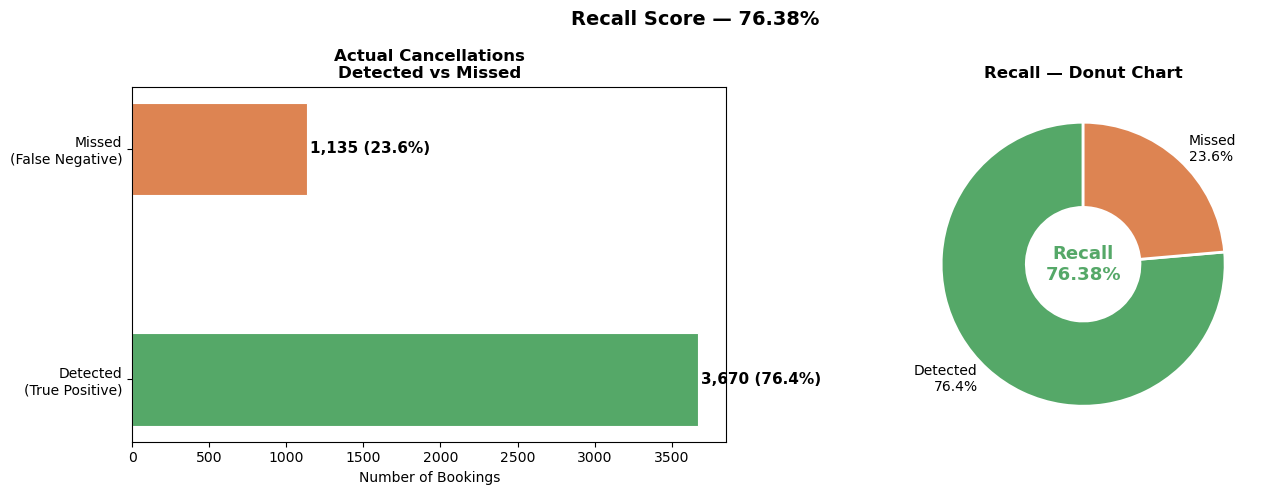

Chart saved: recall_score.png

FINAL RECALL : 76.38%


In [38]:
print("=" * 50)
print("RECALL SCORE")
print("=" * 50)
print()
print("Formula:")
print("Recall = TP / (TP + FN)")
print()
print("Question:")
print("Of all ACTUAL CANCELLED bookings,")
print("how many did the model detect?")
print()

# Calculate
recall = recall_score(y_test, y_pred)

# TP and FN
tp = ((y_pred == 1) & (y_test == 1)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print(f"True Positives  (TP) : {tp:,}")
print(f"  Predicted Cancelled + Actually Cancelled")
print()
print(f"False Negatives (FN) : {fn:,}")
print(f"  Predicted NOT Cancelled + Actually Cancelled")
print()
print(f"Recall Score         : {recall*100:.2f}%")
print()

# Interpretation
print("=" * 50)
print("INTERPRETATION")
print("=" * 50)
if recall >= 0.90:
    print("Excellent! (90%+)")
elif recall >= 0.80:
    print("Very Good! (80-90%)")
elif recall >= 0.70:
    print("Good! (70-80%) ✅")
else:
    print("Needs improvement (below 70%)")
print()
print(f"Out of all ACTUAL cancellations,")
print(f"model detected {recall*100:.2f}% of them!")
print()

# ── Unique Visual — Horizontal Bar Chart ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Recall Score — {recall*100:.2f}%',
             fontsize=14, fontweight='bold')

# Chart 1 — TP vs FN Horizontal Bar
categories = ['Detected\n(True Positive)',
              'Missed\n(False Negative)']
values     = [tp, fn]
colors     = ['#55A868', '#DD8452']

axes[0].barh(categories, values,
             color=colors,
             edgecolor='white',
             linewidth=0.8,
             height=0.4)
axes[0].set_title('Actual Cancellations\nDetected vs Missed',
                  fontweight='bold')
axes[0].set_xlabel('Number of Bookings')

for i, val in enumerate(values):
    axes[0].text(
        val + 20, i,
        f'{val:,} ({val/(tp+fn)*100:.1f}%)',
        va='center',
        fontweight='bold',
        fontsize=11)

# Chart 2 — Donut Chart
total_actual_cancel = tp + fn
detected_pct  = tp / total_actual_cancel * 100
missed_pct    = fn / total_actual_cancel * 100

wedge_sizes   = [tp, fn]
wedge_colors  = ['#55A868', '#DD8452']
wedge_labels  = [f'Detected\n{detected_pct:.1f}%',
                 f'Missed\n{missed_pct:.1f}%']

axes[1].pie(wedge_sizes,
            labels    = wedge_labels,
            colors    = wedge_colors,
            startangle= 90,
            wedgeprops= {'edgecolor': 'white',
                         'linewidth': 2,
                         'width'    : 0.6})
axes[1].text(0, 0,
             f'Recall\n{recall*100:.2f}%',
             ha='center', va='center',
             fontsize=13, fontweight='bold',
             color='#55A868')
axes[1].set_title('Recall — Donut Chart',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('recall_score.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved: recall_score.png")
print()
print("=" * 50)
print(f"FINAL RECALL : {recall*100:.2f}%")
print("=" * 50)

## F1 Score

Precision : 48.47%
Recall    : 76.38%
F1 Score  : 59.31%
Needs improvement!


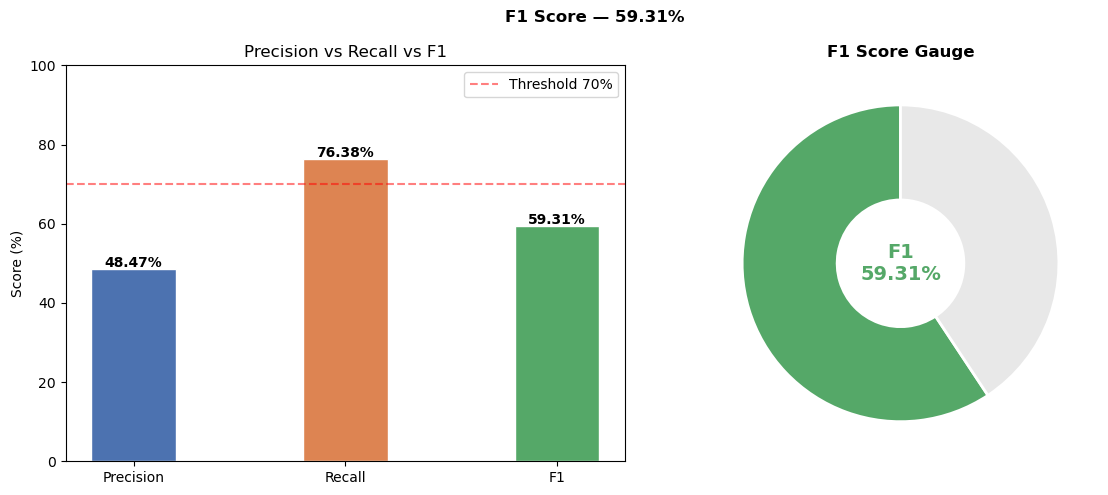

F1 Score: 59.31%


In [54]:
from sklearn.metrics import f1_score, precision_score, recall_score

f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print("Excellent!" if f1 >= 0.90 else
      "Very Good!" if f1 >= 0.80 else
      "Good!"      if f1 >= 0.70 else
      "Acceptable!" if f1 >= 0.60 else
      "Needs improvement!")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'F1 Score — {f1*100:.2f}%',
             fontweight='bold')

bars = axes[0].bar(['Precision','Recall','F1'],
                   [precision*100, recall*100, f1*100],
                   color=['#4C72B0','#DD8452','#55A868'],
                   edgecolor='white', width=0.4)
axes[0].set(ylim=[0,100], ylabel='Score (%)',
            title='Precision vs Recall vs F1')
axes[0].axhline(70, color='red', linestyle='--',
                alpha=0.5, label='Threshold 70%')
axes[0].legend()
[axes[0].text(b.get_x()+b.get_width()/2,
              b.get_height()+0.5, f'{v:.2f}%',
              ha='center', fontweight='bold')
 for b, v in zip(bars,
                 [precision*100, recall*100, f1*100])]

axes[1].pie([f1*100, 100-f1*100],
            colors=['#55A868','#E8E8E8'],
            startangle=90,
            wedgeprops={'edgecolor':'white',
                        'linewidth':2,'width':0.6})
axes[1].text(0, 0, f'F1\n{f1*100:.2f}%',
             ha='center', va='center',
             fontsize=14, fontweight='bold',
             color='#55A868')
axes[1].set_title('F1 Score Gauge', fontweight='bold')

plt.tight_layout()
plt.savefig('f1_score.png', dpi=150)
plt.show()
print(f"F1 Score: {f1*100:.2f}%")

In [40]:
y_test

117514    0
106099    0
38748     0
9323      1
7705      1
         ..
51124     1
73656     1
9790      1
46749     1
1321      0
Name: is_canceled, Length: 17480, dtype: int64

##  y_test and y_pred Check


In [41]:
print("=" * 45)
print("y_test AND y_pred CHECK")
print("=" * 45)
print()

# y_test check
print("y_test (Actual values):")
print(f"  Type    : {type(y_test)}")
print(f"  Shape   : {y_test.shape}")
print(f"  Values  : {y_test.unique()}")
print(f"  Sample  : {list(y_test[:5].values)}")
print()

# y_pred check
print("y_pred (Predicted values):")
print(f"  Type    : {type(y_pred)}")
print(f"  Shape   : {y_pred.shape}")
print(f"  Values  : {set(y_pred)}")
print(f"  Sample  : {list(y_pred[:5])}")
print()

# Compare
print("=" * 45)
print("COMPARISON — FIRST 5")
print("=" * 45)
print(f"{'No':<5} {'y_test':<15} {'y_pred':<15} {'Match'}")
print("-" * 40)
for i in range(5):
    actual    = y_test.iloc[i]
    predicted = y_pred[i]
    match     =  ""if actual == predicted else ""
    print(f"{i+1:<5} {actual:<15} {predicted:<15} {match}")

y_test AND y_pred CHECK

y_test (Actual values):
  Type    : <class 'pandas.core.series.Series'>
  Shape   : (17480,)
  Values  : [0 1]
  Sample  : [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1)]

y_pred (Predicted values):
  Type    : <class 'numpy.ndarray'>
  Shape   : (17480,)
  Values  : {np.int64(0), np.int64(1)}
  Sample  : [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]

COMPARISON — FIRST 5
No    y_test          y_pred          Match
----------------------------------------
1     0               1               
2     0               1               
3     0               1               
4     1               0               
5     1               0               


## Confusion Matrix

CONFUSION MATRIX

True  Negatives (TN): 8,774
  Correctly predicted Not Cancelled

True  Positives (TP): 3,670
  Correctly predicted Cancelled

False Positives (FP): 3,901
  Predicted Cancelled — Actually NOT Cancelled

False Negatives (FN): 1,135
  Predicted NOT Cancelled — Actually Cancelled



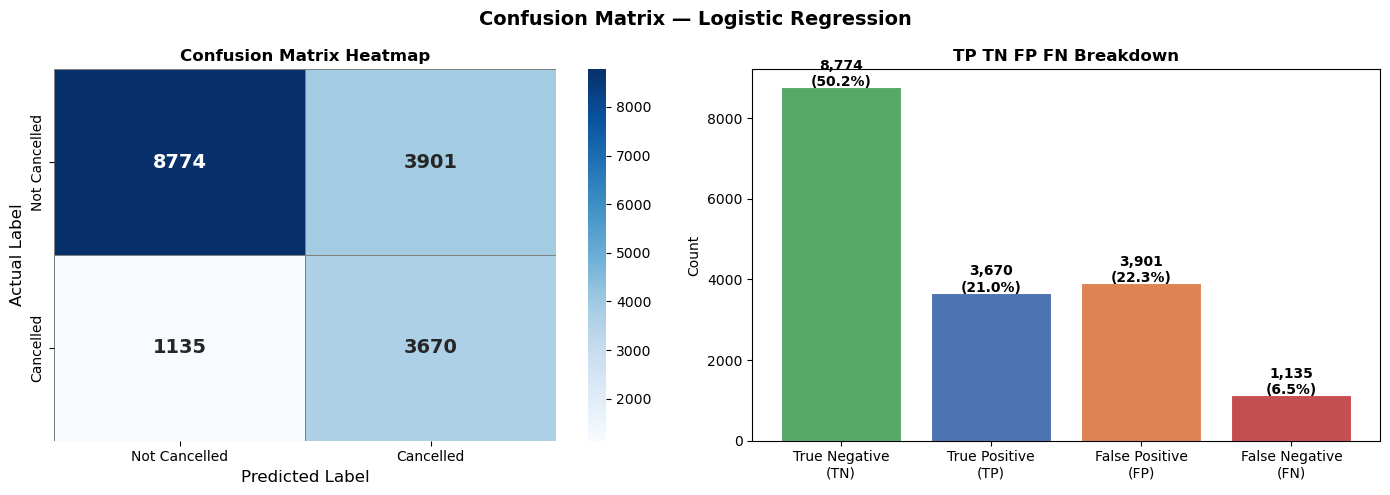

Chart saved: confusion_matrix.png

CONFUSION MATRIX SUMMARY
Total predictions : 17,480
Correct (TN + TP) : 12,444 (71.19%)
Wrong   (FP + FN) : 5,036 (28.81%)

Best result : TN=8,774, TP=3,670
Errors      : FP=3,901, FN=1,135


In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)
print()

# Calculate
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True  Negatives (TN): {tn:,}")
print(f"  Correctly predicted Not Cancelled")
print()
print(f"True  Positives (TP): {tp:,}")
print(f"  Correctly predicted Cancelled")
print()
print(f"False Positives (FP): {fp:,}")
print(f"  Predicted Cancelled — Actually NOT Cancelled")
print()
print(f"False Negatives (FN): {fn:,}")
print(f"  Predicted NOT Cancelled — Actually Cancelled")
print()

# ── Visual ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Logistic Regression',
             fontsize=14, fontweight='bold')

# ── Chart 1: Heatmap ──────────────────────────────────────
cm_labels = ['Not Cancelled', 'Cancelled']
sns.heatmap(cm,
            annot     = True,
            fmt       = 'd',
            cmap      = 'Blues',
            xticklabels = cm_labels,
            yticklabels = cm_labels,
            linewidths  = 0.5,
            linecolor   = 'gray',
            annot_kws   = {'size': 14,
                           'fontweight': 'bold'},
            ax          = axes[0])
axes[0].set_title('Confusion Matrix Heatmap',
                  fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# ── Chart 2: TP TN FP FN Bar Chart ───────────────────────
categories = ['True Negative\n(TN)',
              'True Positive\n(TP)',
              'False Positive\n(FP)',
              'False Negative\n(FN)']
values     = [tn, tp, fp, fn]
colors     = ['#55A868', '#4C72B0',
              '#DD8452', '#C44E52']

bars = axes[1].bar(categories, values,
                   color=colors,
                   edgecolor='white',
                   linewidth=0.8)
axes[1].set_title('TP TN FP FN Breakdown',
                  fontweight='bold')
axes[1].set_ylabel('Count')
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f'{val:,}\n({val/len(y_pred)*100:.1f}%)',
        ha='center',
        fontweight='bold',
        fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: confusion_matrix.png")
print()
print("=" * 50)
print("CONFUSION MATRIX SUMMARY")
print("=" * 50)
print(f"Total predictions : {len(y_pred):,}")
print(f"Correct (TN + TP) : {tn+tp:,} "
      f"({(tn+tp)/len(y_pred)*100:.2f}%)")
print(f"Wrong   (FP + FN) : {fp+fn:,} "
      f"({(fp+fn)/len(y_pred)*100:.2f}%)")
print()
print(f"Best result : TN={tn:,}, TP={tp:,}")
print(f"Errors      : FP={fp:,}, FN={fn:,}")

## AUC-ROC Scor

AUC-ROC : 0.8033 (80.33%)
Good!


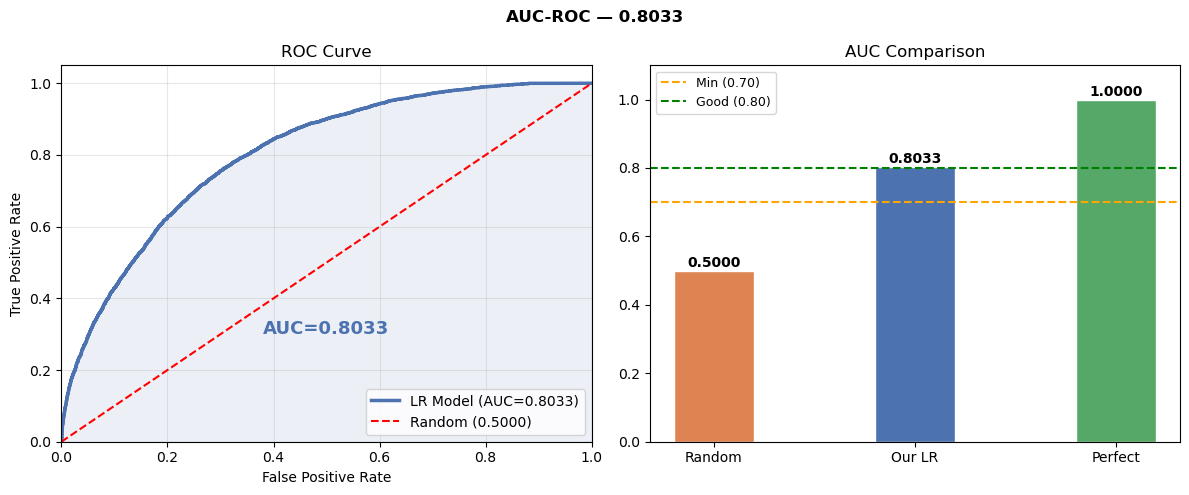

AUC-ROC : 0.8033 (80.33%)


In [53]:
from sklearn.metrics import roc_auc_score, roc_curve

y_proba_1d      = log_reg.predict_proba(X_test_scaled)[:,1]
auc             = roc_auc_score(y_test, y_proba_1d)
fpr, tpr, _     = roc_curve(y_test, y_proba_1d)

print(f"AUC-ROC : {auc:.4f} ({auc*100:.2f}%)")
print("Good!" if auc >= 0.80 else "Acceptable!" 
      if auc >= 0.70 else "Needs improvement!")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'AUC-ROC — {auc:.4f}', fontweight='bold')

axes[0].plot(fpr, tpr, color='#4C72B0', linewidth=2.5,
             label=f'LR Model (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1], 'r--', label='Random (0.5000)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
axes[0].set(xlabel='False Positive Rate',
            ylabel='True Positive Rate',
            title='ROC Curve', xlim=[0,1], ylim=[0,1.05])
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)
axes[0].annotate(f'AUC={auc:.4f}', xy=(0.5,0.3),
                 fontsize=13, fontweight='bold',
                 color='#4C72B0', ha='center')

bars = axes[1].bar(['Random','Our LR','Perfect'],
                   [0.5, auc, 1.0],
                   color=['#DD8452','#4C72B0','#55A868'],
                   edgecolor='white', width=0.4)
axes[1].axhline(0.70, color='orange', linestyle='--',
                label='Min (0.70)')
axes[1].axhline(0.80, color='green', linestyle='--',
                label='Good (0.80)')
axes[1].set(ylim=[0,1.1], title='AUC Comparison')
axes[1].legend(fontsize=9)
[axes[1].text(b.get_x()+b.get_width()/2,
              b.get_height()+0.01, f'{v:.4f}',
              ha='center', fontweight='bold')
 for b, v in zip(bars, [0.5, auc, 1.0])]

plt.tight_layout()
plt.savefig('auc_roc_score.png', dpi=150)
plt.show()
print(f"AUC-ROC : {auc:.4f} ({auc*100:.2f}%)")

In [44]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


## Training & Testing Scores (Logistic Regression)

In [45]:

# Training Scores
train_pred = log_reg.predict(X_train_smote)
tr_acc  = accuracy_score(y_train_smote, train_pred)
tr_prec = precision_score(y_train_smote, train_pred)
tr_rec  = recall_score(y_train_smote, train_pred)
tr_f1   = f1_score(y_train_smote, train_pred)

# Testing Scores
test_pred = log_reg.predict(X_test_scaled)
te_acc  = accuracy_score(y_test, test_pred)
te_prec = precision_score(y_test, test_pred)
te_rec  = recall_score(y_test, test_pred)
te_f1   = f1_score(y_test, test_pred)

# ── Print ─────────────────────────────────────────────────
print("Training Scores:")
print(f"        Accuracy  = {tr_acc:.3f}")
print(f"        Precision = {tr_prec:.3f}")
print(f"        Recall    = {tr_rec:.3f}")
print(f"        F1-Score  = {tr_f1:.3f}")
print("Testing Scores:")
print(f"        Accuracy  = {te_acc:.3f}")
print(f"        Precision = {te_prec:.3f}")
print(f"        Recall    = {te_rec:.3f}")
print(f"        F1-Score  = {te_f1:.3f}")

Training Scores:
        Accuracy  = 0.735
        Precision = 0.716
        Recall    = 0.776
        F1-Score  = 0.745
Testing Scores:
        Accuracy  = 0.712
        Precision = 0.485
        Recall    = 0.764
        F1-Score  = 0.593


## Feature Coefficients

TOP 10 FEATURE COEFFICIENTS
---------------------------------------------
required_car_parking_spaces          -5.4905 (Safe)
market_segment                        1.0775 (Cancel)
assigned_room_type                   -1.0046 (Safe)
reserved_room_type                    0.8733 (Cancel)
previous_cancellations                0.7132 (Cancel)
distribution_channel                 -0.6089 (Safe)
total_of_special_requests            -0.5224 (Safe)
country                               0.4640 (Cancel)
previous_bookings_not_canceled       -0.4010 (Safe)
lead_time                             0.3109 (Cancel)


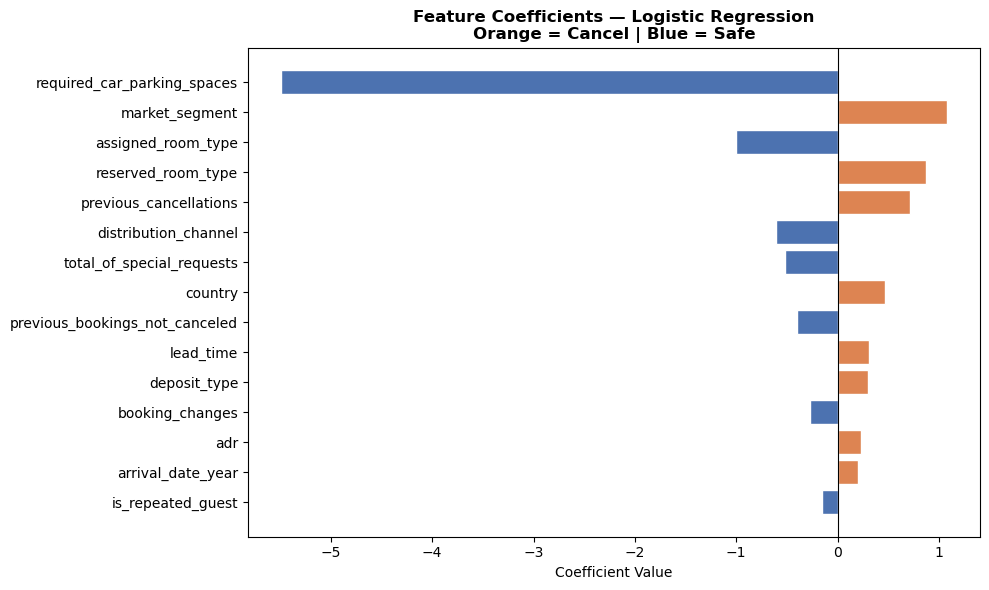

Chart saved: feature_coefficients.png


In [48]:
coef_df = pd.DataFrame({
    'Feature'    : list(X.columns),
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("TOP 10 FEATURE COEFFICIENTS")
print("-" * 45)
for _, row in coef_df.head(10).iterrows():
    direction = "Cancel" if row['Coefficient'] > 0 \
                else "Safe"
    print(f"{row['Feature']:<35} "
          f"{row['Coefficient']:>8.4f} "
          f"({direction})")

# ── Visual ────────────────────────────────────────────────
top15  = coef_df.head(15)
colors = ['#DD8452' if c > 0 else '#4C72B0'
          for c in top15['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top15['Feature'],
         top15['Coefficient'],
         color=colors,
         edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Coefficients — Logistic Regression\n'
          'Orange = Cancel | Blue = Safe',
          fontweight='bold')
plt.xlabel('Coefficient Value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: feature_coefficients.png")

## 5-Fold Cross Validation

5-FOLD CROSS VALIDATION
-----------------------------------
  Fold 1: 73.62%
  Fold 2: 73.03%
  Fold 3: 73.57%
  Fold 4: 73.49%
  Fold 5: 73.43%
-----------------------------------
  Mean : 73.43%
  Std  : 0.21%

Model STABLE!


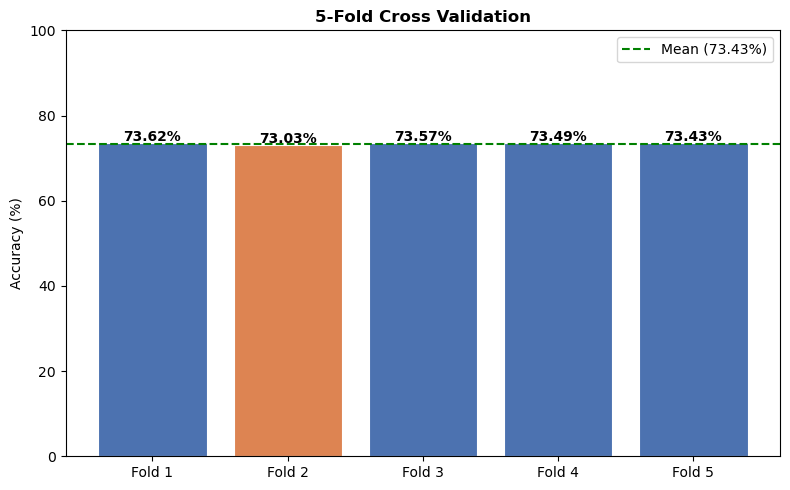

Chart saved: cross_validation.png


In [49]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_smote, y_train_smote, cv=cv, scoring='accuracy')

print("5-FOLD CROSS VALIDATION")
print("-" * 35)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score*100:.2f}%")
print("-" * 35)
print(f"  Mean : {cv_scores.mean()*100:.2f}%")
print(f"  Std  : {cv_scores.std()*100:.2f}%")
print()
print("Model STABLE!" if cv_scores.std() < 0.02
      else "Some variation across folds")

# ── Visual ────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
colors = ['#4C72B0' if s >= cv_scores.mean()
          else '#DD8452' for s in cv_scores]
bars = plt.bar([f'Fold {i}' for i in range(1,6)],
               cv_scores*100, color=colors,
               edgecolor='white', linewidth=0.8)
plt.axhline(y=cv_scores.mean()*100, color='green',
            linestyle='--',
            label=f'Mean ({cv_scores.mean()*100:.2f}%)')
plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('5-Fold Cross Validation', fontweight='bold')
plt.legend()
for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val*100:.2f}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cross_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: cross_validation.png")

## Hyperparameter Tuning

HYPERPARAMETER TUNING — C VALUE
----------------------------------------
C=0.001  → 70.74% <- Best!
C=0.01   → 71.12% <- Best!
C=0.1    → 71.18% <- Best!
C=1.0    → 71.19% <- Best!
C=10     → 71.18%
C=100    → 71.16%

Best C=1.0, Accuracy=71.19%


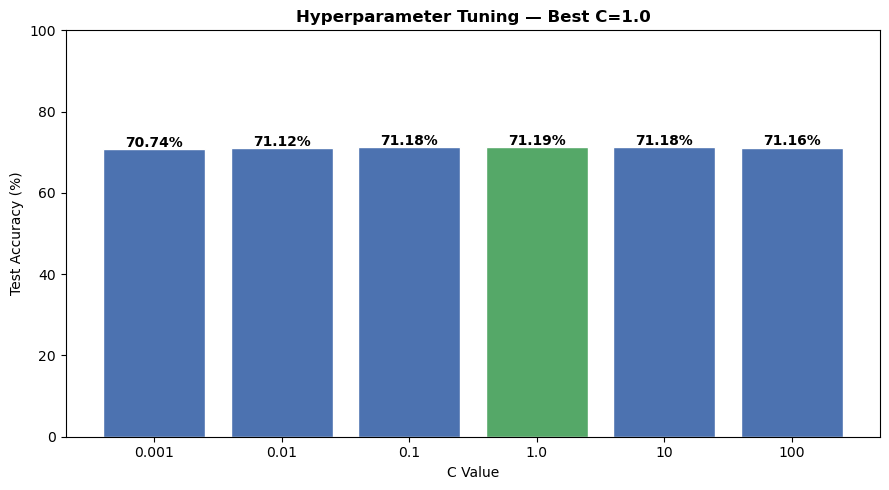

Chart saved: hyperparameter_tuning.png


In [50]:
from sklearn.metrics import accuracy_score

print("HYPERPARAMETER TUNING — C VALUE")
print("-" * 40)

c_values = [0.001, 0.01, 0.1, 1.0, 10, 100]
best_acc, best_c, results = 0, 1.0, []

for c in c_values:
    m = LogisticRegression(solver='lbfgs',
                           max_iter=1000,
                           C=c, random_state=42)
    m.fit(X_train_smote, y_train_smote)
    acc = accuracy_score(y_test,
                         m.predict(X_test_scaled))
    results.append(acc*100)
    if acc > best_acc:
        best_acc, best_c = acc, c
    print(f"C={c:<6} → {acc*100:.2f}%"
          + (" <- Best!" if c == best_c else ""))

print(f"\nBest C={best_c}, Accuracy={best_acc*100:.2f}%")

# Visual
colors = ['#55A868' if c == best_c
          else '#4C72B0' for c in c_values]
plt.figure(figsize=(9, 5))
bars = plt.bar([str(c) for c in c_values],
               results, color=colors,
               edgecolor='white')
plt.title(f'Hyperparameter Tuning — Best C={best_c}',
          fontweight='bold')
plt.xlabel('C Value')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100)
for bar, val in zip(bars, results):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.2f}%',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparameter_tuning.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: hyperparameter_tuning.png")

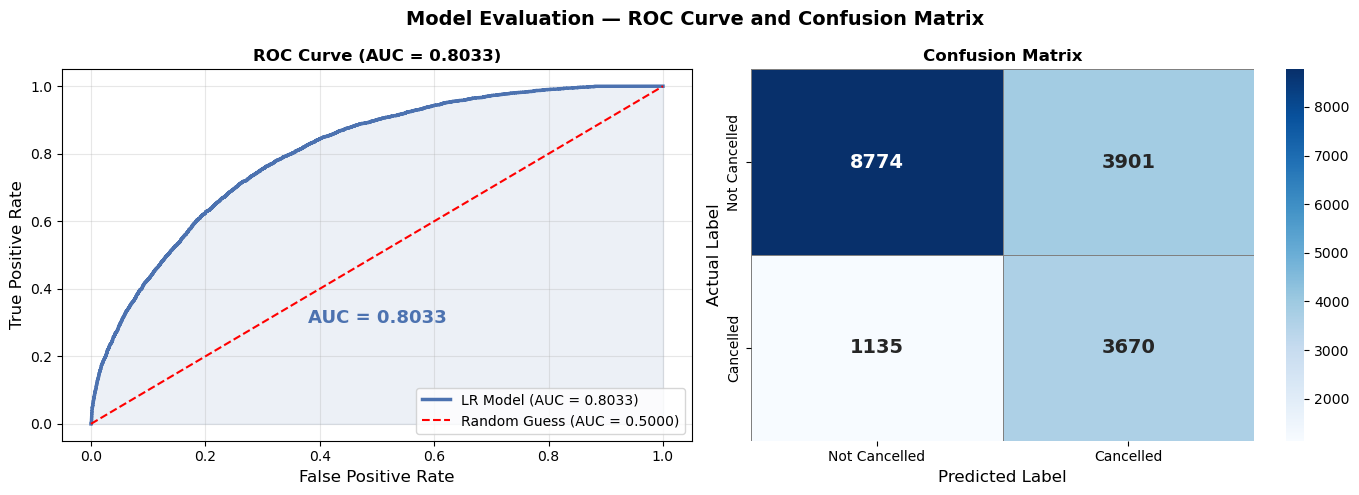

RESULTS SUMMARY
AUC-ROC Score : 0.8033 (80.33%)

True  Negatives (TN): 8,774
True  Positives (TP): 3,670
False Positives (FP): 3,901
False Negatives (FN): 1,135

Correct   : 12,444 (71.19%)
Wrong     : 5,036 (28.81%)
Chart saved: roc_confusion_matrix.png


In [51]:
# ── ROC-AUC and Confusion Matrix ──────────────────────────
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix)
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Evaluation — ROC Curve and Confusion Matrix',
             fontsize=14, fontweight='bold')

# ── ROC Curve ─────────────────────────────────────────────
y_proba_1d = log_reg.predict_proba(X_test_scaled)[:, 1]
auc        = roc_auc_score(y_test, y_proba_1d)
fpr, tpr, _ = roc_curve(y_test, y_proba_1d)

axes[0].plot(fpr, tpr,
             color='#4C72B0', linewidth=2.5,
             label=f'LR Model (AUC = {auc:.4f})')
axes[0].plot([0,1], [0,1],
             color='red', linewidth=1.5,
             linestyle='--',
             label='Random Guess (AUC = 0.5000)')
axes[0].fill_between(fpr, tpr,
                     alpha=0.1, color='#4C72B0')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title(f'ROC Curve (AUC = {auc:.4f})',
                  fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'AUC = {auc:.4f}',
                 xy=(0.5, 0.3), fontsize=13,
                 fontweight='bold', color='#4C72B0',
                 ha='center')

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,
            annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'],
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 14, 'fontweight': 'bold'},
            ax=axes[1])
axes[1].set_title('Confusion Matrix',
                  fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('roc_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print Results ─────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print("=" * 45)
print("RESULTS SUMMARY")
print("=" * 45)
print(f"AUC-ROC Score : {auc:.4f} ({auc*100:.2f}%)")
print()
print(f"True  Negatives (TN): {tn:,}")
print(f"True  Positives (TP): {tp:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print()
print(f"Correct   : {tn+tp:,} ({(tn+tp)/len(y_pred)*100:.2f}%)")
print(f"Wrong     : {fp+fn:,} ({(fp+fn)/len(y_pred)*100:.2f}%)")
print("Chart saved: roc_confusion_matrix.png")

ORIGINAL (L2) vs IMPROVED (L1)
Metric         Original   Improved
-----------------------------------
Accuracy         71.19%     71.16% ↓
Precision        48.47%     48.44% ↓
Recall           76.38%     76.36% ↓
F1 Score         59.31%     59.28% ↓


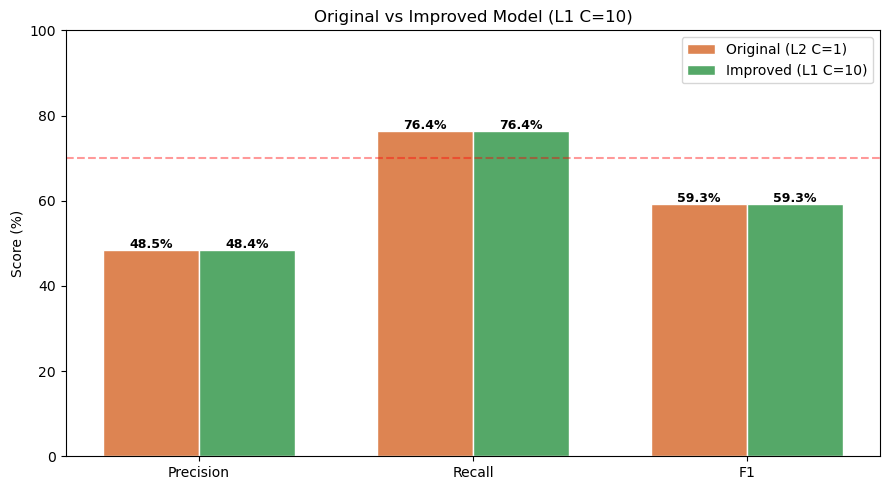

Chart saved: improved_model.png


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score,
                             recall_score,
                             f1_score,
                             accuracy_score)

# ── L1 Model — C=10 ───────────────────────────────────────
lr_l1 = LogisticRegression(
    solver      = 'liblinear',
    max_iter    = 1000,
    C           = 10,        # ← C=0.1 → C=10
    penalty     = 'l1',
    random_state= 42
)
lr_l1.fit(X_train_smote, y_train_smote)
y_l1 = lr_l1.predict(X_test_scaled)

# ── Results ───────────────────────────────────────────────
print("=" * 45)
print("ORIGINAL (L2) vs IMPROVED (L1)")
print("=" * 45)
print(f"{'Metric':<12} {'Original':>10} {'Improved':>10}")
print("-" * 35)
for name, orig, impr in [
    ('Accuracy',
     accuracy_score(y_test, y_pred),
     accuracy_score(y_test, y_l1)),
    ('Precision',
     precision_score(y_test, y_pred),
     precision_score(y_test, y_l1)),
    ('Recall',
     recall_score(y_test, y_pred),
     recall_score(y_test, y_l1)),
    ('F1 Score',
     f1_score(y_test, y_pred),
     f1_score(y_test, y_l1))
]:
    arrow = "↑" if impr > orig else "↓"
    print(f"{name:<12} {orig*100:>9.2f}% "
          f"{impr*100:>9.2f}% {arrow}")

# ── Visual ────────────────────────────────────────────────
metrics = ['Precision', 'Recall', 'F1']
orig    = [precision_score(y_test,y_pred)*100,
           recall_score(y_test,y_pred)*100,
           f1_score(y_test,y_pred)*100]
impr    = [precision_score(y_test,y_l1)*100,
           recall_score(y_test,y_l1)*100,
           f1_score(y_test,y_l1)*100]

x, w = range(3), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar([i-w/2 for i in x], orig, w,
            label='Original (L2 C=1)',
            color='#DD8452', edgecolor='white')
b2 = ax.bar([i+w/2 for i in x], impr, w,
            label='Improved (L1 C=10)',
            color='#55A868', edgecolor='white')
ax.set(ylim=[0,100], ylabel='Score (%)',
       title='Original vs Improved Model (L1 C=10)')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.legend()
ax.axhline(70, color='red',
           linestyle='--', alpha=0.4)
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2,
                b.get_height()+0.5,
                f'{b.get_height():.1f}%',
                ha='center', fontsize=9,
                fontweight='bold')
plt.tight_layout()
plt.savefig('improved_model.png', dpi=150)
plt.show()
print("Chart saved: improved_model.png")